# 알고리즘 기말 프로젝트 — Score Function Design

- **제출일**: `2026.06.21`
- **파일명**: `김나연_20250786_drug.ipynb`

## 학번 / 이름

- **학번**: `20250786`
- **이름**: `김나연`
- **score에 대한 간략한 설명**:  `drug`-likeness를 계산하는 score
    - Drug-likeness 스코어링 시스템 개요
    - 화합물의 물리화학적 속성과 고유 구조 패턴(골격/잔기)을 기반으로 임의의 화합물이 실제 약물의 물성 및 구조적 특징을 얼마나 닮았는지 정량화하는 스코어링 시스템 구현

## 채점 기준 (100점)

| 영역 | 배점 | 만점 기준 |
|---|---|---|
| **(1) Negative 데이터 준비** | 20 | "구조 유사도"를 통해 negative 집합을 찾아낸 기준? (유사도 측정 방법 & Structural similarity 기준 설정) |
| **(2) Score 함수 설계** | 20 | **(a) 분자 속성 범위 (전체 데이터에서 property 범위 계산 방식)** + **(b) alert 구조 패턴(scaffold 및 부분 구조의 smarts 패턴)** 두 요소 모두 포함. score에 대한 설명은 markdown에 기재. |
| **(3) Score 평가 — goodness** | 20 | positive vs negative 점수 분포 비교 (히스토그램/ROC/AUC 등 score 성능의 근거가 되는 시각화 자료 제시) |
| **(4) 설명** | 10 | 각 알고리즘을 mermaid를 이용해서 표현하고 설명글 추가 (markdown 및 주석으로 표기) |


### 가산점 (선택)

| 가산 | 점수 | 조건 |
|---|---|---|
| **(A) 다른 화학 제품군 score** | +10 | pesticide 외 1종 이상(cosmetic / food additive / fragrance / surfactant / dye 등)의 PubChem classification 데이터로 별도 score 함수 설계 + 평가 |
| **(B) Score 기반 구조 생성** | +10 | 본인 score 를 reward 로 사용해 score가 개선된 새로운 구조 생성. |
| **(C) 계산 자원과 계산 시간** | +10 | mpi를 이용해서 대량의 자원으로 계산 시간을 대폭 줄이거나, local 환경에서 합리적으로 계산이 진행될 수 있도록 문제를 효율적으로 압축시킨 방법 적용 (mpi script와 계산 결과에 대한 log 필요) |

### 제출 결과물 (결과를 재현하기 위해 필요한 파일들)
1. ipynb (mpi를 사용했다면, mpi4py script)
2. data files (drug, cosmetics, food additives, drug, ..., format: csv)
3. negative list file (format: csv)
4. score 평가 시각화 자료 (mpi에서 실행해서 얻은 plot은 notebook markdown에 삽입)

---
# Task 1. Negative 데이터 준비 (25점)
**문제**: 양성(positive) 분자와 "구조적으로 다른" 분자 집합을 어떻게 만들 것인가?
Score 함수의 평가는 **양성과 음성을 얼마나 잘 구분하는가** 로 측정한다. 그러려면 먼저 음성 집합을 정의해야 한다.

**📝 본인 선택과 이유 (직접 작성):**

- **선택한 기준**:
    1. **음성 대조군용 ZINC 데이터 로드 및 표준화**: ZINC 데이터베이스로부터 분자들을 불러와 표준화하고 중복을 제거한 후, 양성 약물군에 존재하는 분자들을 제거한다.
  2. **구조 유사도 필터링 (Structural Similarity Filter)**: 2048-bit Morgan Fingerprint (radius=2)와 Tanimoto Coefficient를 사용해 양성군과의 최대 구조 유사도를 계산한다. 양성군 자가 유사도 분포와 ZINC 후보군 유사도 분포의 교차점(Crossing Point)을 동적으로 계산하여 최적의 Cutoff를 자동 결정한다.
  3. **음성 데이터 선별 개수 (N=양성 대비 1:1 균형 및 무작위 추출)**: Cutoff 이하를 만족하는 ZINC 후보 분자들을 대상으로, 양성 데이터 크기(N=3,085) 한도 내에서 무작위 추출(Random Sampling)을 수행한다.

- **이유**:
  1. **ZINC 데이터 사용 및 표준화 이유**: 양성군(약물)과 명확히 구분되는 대조군을 형성하기 위해 ZINC 화학 라이브러리 데이터를 사용하고, 표준화 및 중복 제거를 통해 분석의 정밀도를 높이기 위함이다.
  2. **구조 유사도 필터링 및 동적 Cutoff 적용 이유**: 분석가가 고정된 임계치를 임의로 정하는 대신, 양성군 내부의 자가 유사도 분포와 ZINC 후보군의 유사도 분포가 만나는 교차점을 계산하여 자동으로 설정한다. 이를 통해 고정된 수치가 아닌, 실제 데이터의 유사도 분포 특성을 반영한 객관적인 기준을 유연하게 도출하기 위함이다.
  3. **전체 파일 대신 일부 파일 무작위 샘플링 및 균형 크기 추출 이유**:
    - ZINC의 68개 전체 파일을 다 돌리면 연산 시간이 48시간 이상 소요되어 완료되지 않는 병목이 발생하며, 최종 선별할 데이터(3,085개)보다 필요 이상으로 많은 양의 데이터가 수집되어 비효율적이다.
    - 이에 따라 필요한 개수의 약 100배 크기의 충분한 후보 풀이 모일 때까지만 일부 파일을 무작위로 골라 스캔하여 연산 낭비를 차단했다.
    - 이후 수집된 후보 풀에서 최종적으로 양성 데이터 개수에 맞게 무작위 추출을 수행하여 학습의 균형을 맞춘다.

In [1]:
# 라이브러리 임포트 및 경고 메시지 차단
import warnings
warnings.filterwarnings('ignore')

import io
import re
import time
import base64
import math
import glob
import random
import platform
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
from pathlib import Path
from scipy.stats import skew, gaussian_kde
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from rdkit import Chem, RDLogger
from rdkit.Chem import Draw, Descriptors, Crippen, MACCSkeys, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.rdMolDescriptors import GetMorganFingerprintAsBitVect, GetTopologicalTorsionFingerprint
from rdkit.DataStructs import BulkTanimotoSimilarity

from sklearn.metrics import (
    roc_auc_score, roc_curve, auc, average_precision_score, 
    accuracy_score, balanced_accuracy_score, precision_score, 
    recall_score, f1_score, matthews_corrcoef, precision_recall_curve,
    confusion_matrix
)
from IPython.display import display, HTML, Markdown, Image as IPImage

import inspect
import json
import re
from IPython.display import display, Markdown

RDLogger.DisableLog('rdApp.warning')
RDLogger.DisableLog('rdApp.error')


In [ ]:
# 1. 양성(Positive) 약물 데이터 로드 및 RDKit Canonical smiles 표준화 처리
pos_df = pd.read_csv('PubChem_Drugs.csv')
pos_df.columns = pos_df.columns.str.lower()
pos_df = pos_df.dropna(subset=['smiles']).copy()
pos_df['mol'] = [Chem.MolFromSmiles(s) for s in pos_df['smiles']]
pos_df = pos_df[pos_df['mol'].notna()].copy()
pos_df['standardized_smi'] = [Chem.MolToSmiles(m) for m in pos_df['mol']]
pos_df = pos_df.drop_duplicates(subset='standardized_smi').reset_index(drop=True)
pos_df['smiles'] = pos_df['standardized_smi']
pos_smi_set = set(pos_df['standardized_smi'])

# Fingerprint Generator (Morgan FP, 반경 2, 2048 비트) 생성
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
ref_fps = [fp_gen.GetFingerprint(m) for m in pos_df['mol']]

print(f"양성 데이터(Drug) 수량: {len(pos_df)}개")

양성 데이터(Drug) 수량: 15361개



### 3. 소규모(파일 10개) MPI 분산 처리 테스트 결과 확인

- **실행 스크립트**: `task1/kisti0618testdrug/0618_testnegative_data.sh`
- **MPI 코드**: `task1/kisti0618testdrug/negative_drug_data_kisti.py.py`

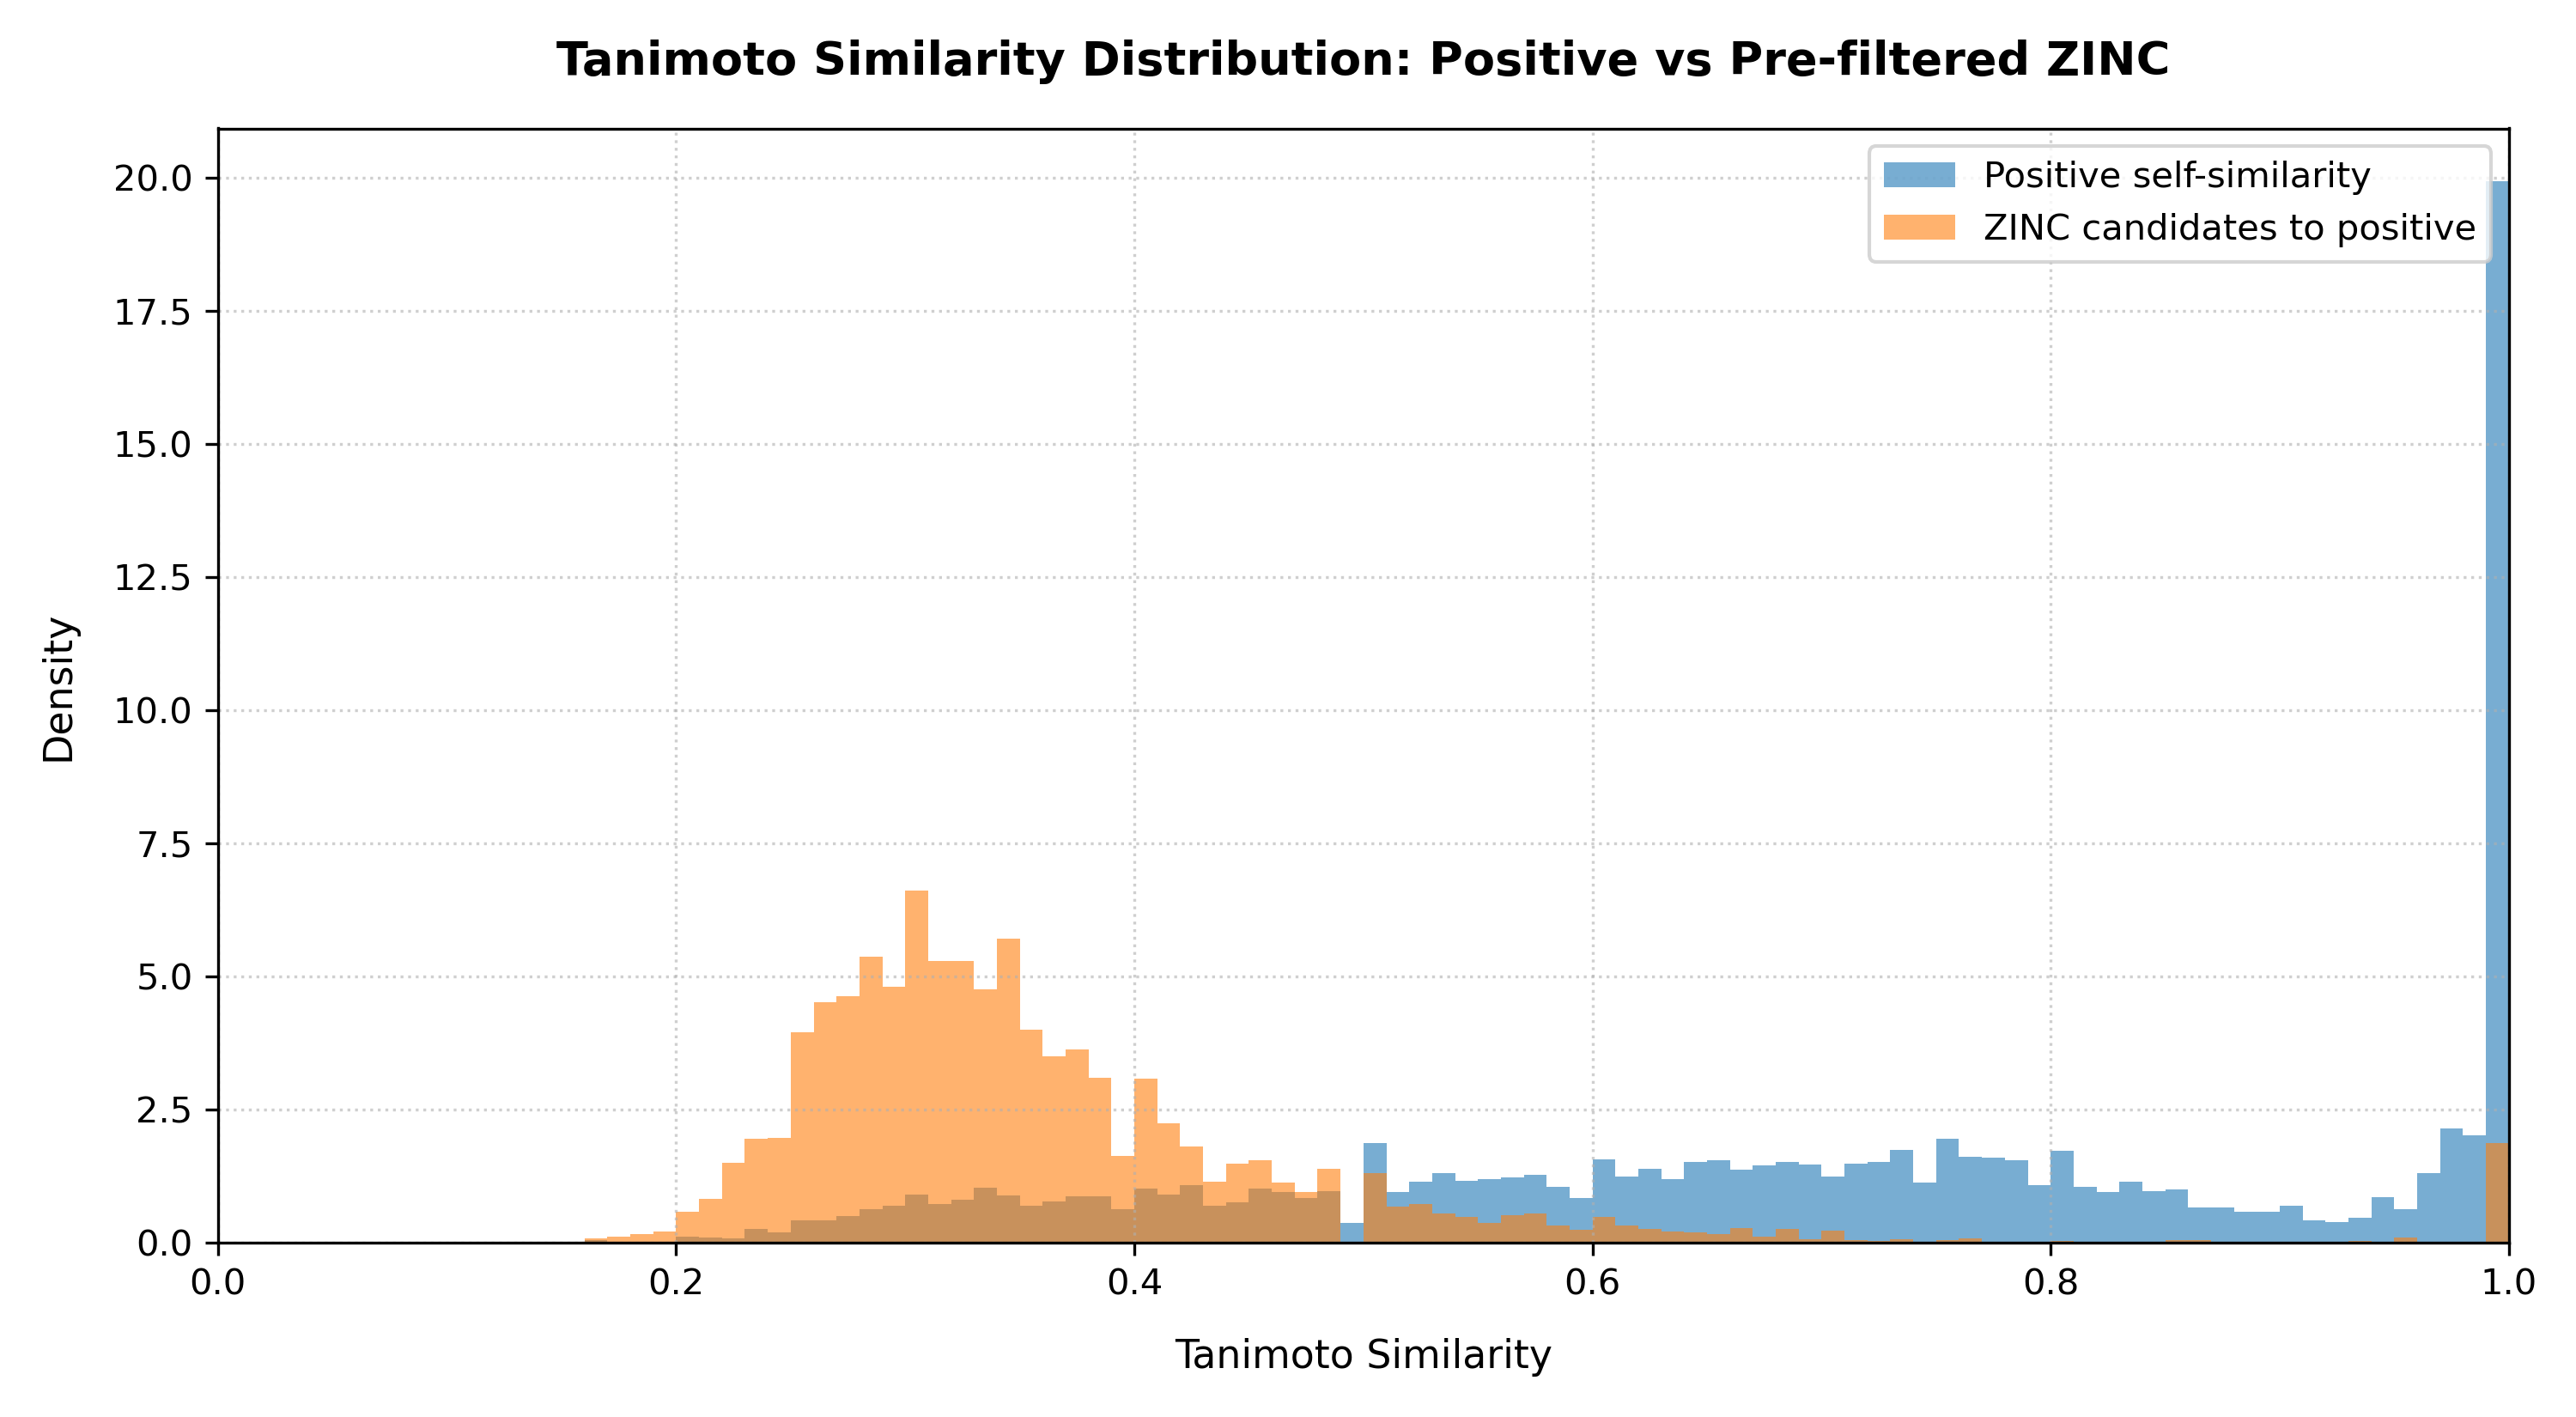

In [8]:
# 소규모 테스트에서 생성된 양성 자가유사도 vs ZINC 유사도 분포 비교 그래프 출력
display(IPImage(filename='task1/kisti0618testdrug/dtest_distribution_comparison_raw.png', width=600))

[Task 1 Execution Metadata - KISTI MPI (Random Target Subsampling Version)]
Tanimoto Cutoff: 0.4400
Total Drug Positives: 15361
Total Selected Negatives: 15361
Random Sampling Seed: 64163
Testing Mode Enabled: False



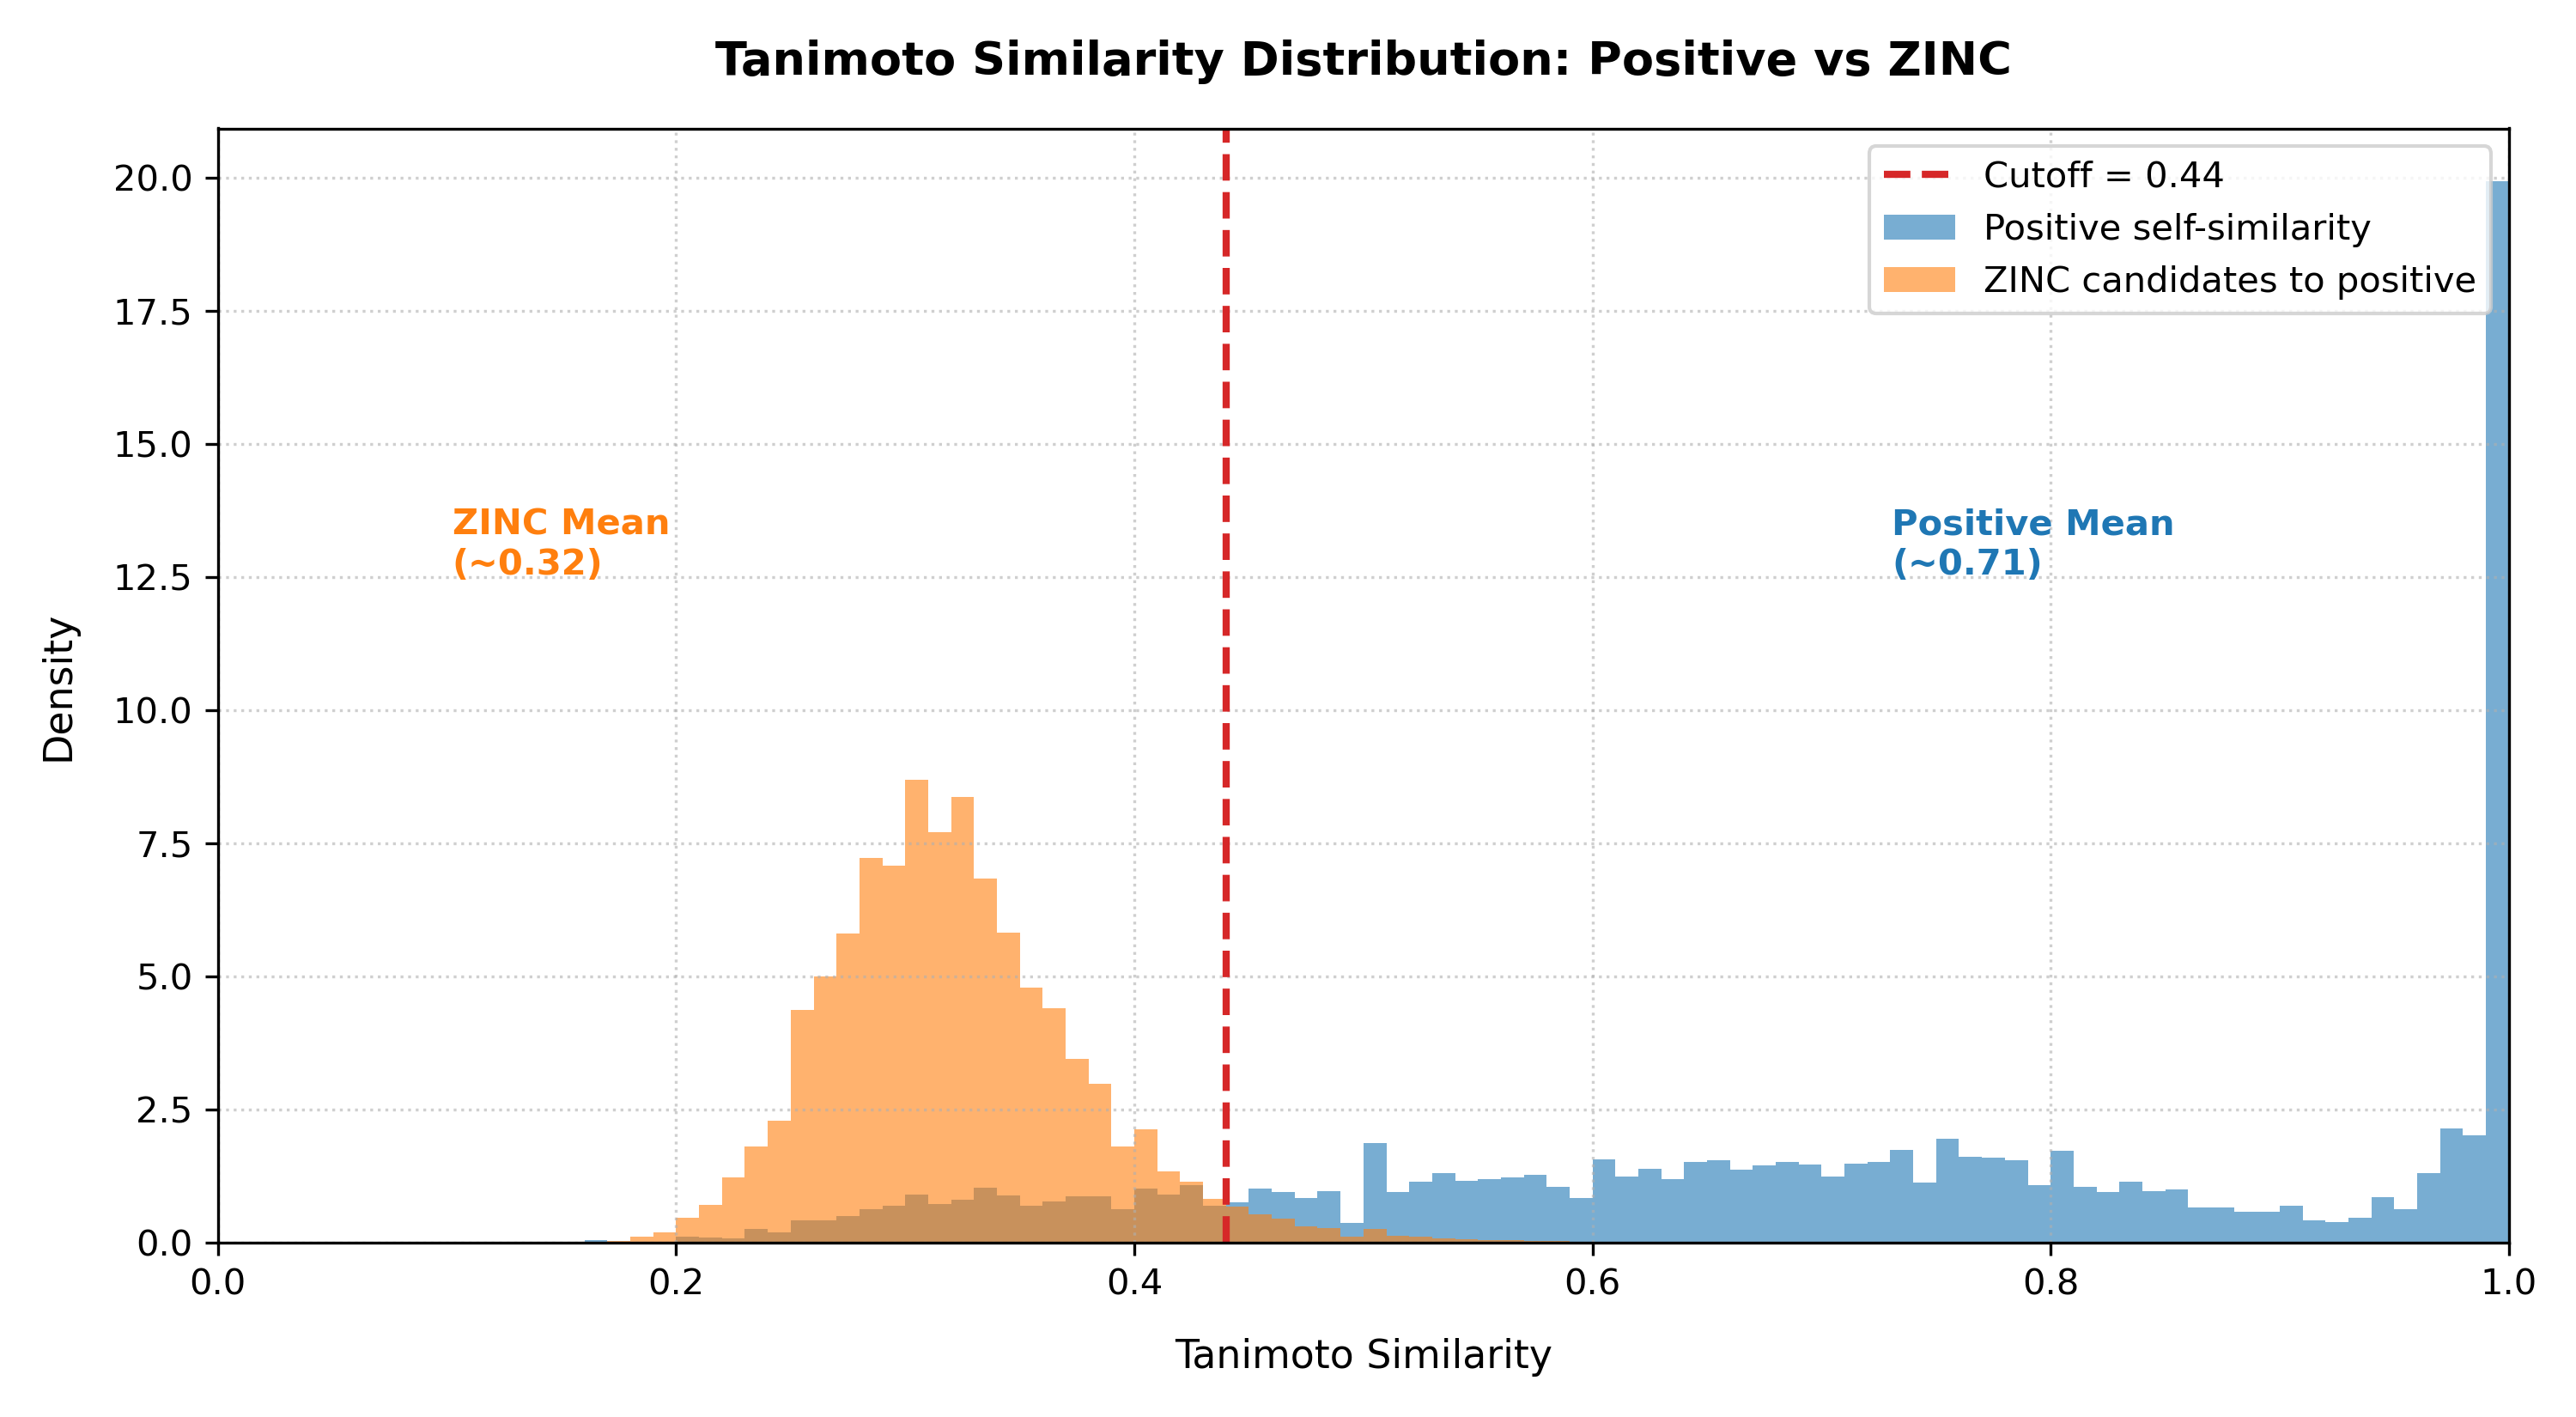

In [22]:
# 4. 최종 MPI 계산 결과를 바탕으로 한 양성군 vs ZINC 후보군 유사도 분포 확인

result_dir = Path('task1/kisti0620finaldrug')
metadata_path = result_dir / 'dnegative_metadata.txt'
final_neg_path = result_dir / 'dnegative_drug_vs_zinc.csv'
candidate_path = result_dir / 'dnegative_candidates_before_sampling.csv'
plot_path = result_dir / 'ddistribution_comparison.png'
raw_plot_path = result_dir / 'ddistribution_comparison_raw.png'
cutoff_plot_path = result_dir / 'ddistribution_comparison_cutoff.png'

# 메타데이터 및 최종 음성 데이터 로드
print(metadata_path.read_text(encoding='utf-8'))

# MPI에서 생성한 최종 분포 그래프 출력
display(IPImage(filename=str(plot_path), width=750))


In [23]:
# Task 1. MPI 분산 처리 결과 및 대조군 선별 개요 수치 동적 출력

result_dir = Path('task1/kisti0620finaldrug')
metadata_path = result_dir / 'dnegative_metadata.txt'
candidate_path = result_dir / 'dnegative_candidates_before_sampling.csv'

# 1. 
cutoff = 0.49

# 2. 메타데이터 파싱
metadata_content = metadata_path.read_text(encoding='utf-8')
selected_negatives = int(re.search(r'Total Selected Negatives:\s*(\d+)', metadata_content).group(1))

# 3. Cutoff 이하 1차 음성 후보군 수 계산
with open(candidate_path, 'r', encoding='utf-8') as f:
    cutoff_negatives = sum(1 for _ in f) - 1

# 4. 마크다운 출력
markdown_text = f"""
### **MPI 실험 및 최종 음성 데이터 선별**

**실행 파일 및 결과 보관 경로:**
- 결과 폴더: `task1/kisti0620finaldrug/`
- MPI 코드: `task1/kisti0620finaldrug/negative_data_kisti5.py`
- 실행 로그: `task1/kisti0620finaldrug/run_log.txt`
- 메타데이터: `task1/kisti0620finaldrug/dnegative_metadata.txt`
- 최종 음성 CSV: `task1/kisti0620finaldrug/dnegative_drug_vs_zinc.csv`
- 전체 후보 CSV: `task1/kisti0620finaldrug/dnegative_candidates_before_sampling.csv`

**결과:**
- 최적 Cutoff: **`{cutoff:.2f}`**
- Cutoff 이하 1차 음성 후보군 수: **`{cutoff_negatives:,}개`**
- 최종 1:1 샘플링 음성 데이터 수: **`{selected_negatives:,}개`**
- 총 소요 시간(Walltime): **약 `01:43:20`**
  - 로그에 기록된 1패스 시간과 결과 파일 생성 시각 차이를 함께 사용하여 산출하였다.

"""
display(Markdown(markdown_text))



### **MPI 실험 및 최종 음성 데이터 선별**

**실행 파일 및 결과 보관 경로:**
- 결과 폴더: `task1/kisti0620finaldrug/`
- MPI 코드: `task1/kisti0620finaldrug/negative_data_kisti5.py`
- 실행 로그: `task1/kisti0620finaldrug/run_log.txt`
- 메타데이터: `task1/kisti0620finaldrug/dnegative_metadata.txt`
- 최종 음성 CSV: `task1/kisti0620finaldrug/dnegative_drug_vs_zinc.csv`
- 전체 후보 CSV: `task1/kisti0620finaldrug/dnegative_candidates_before_sampling.csv`

**결과:**
- 최적 Cutoff: **`0.49`**
- Cutoff 이하 1차 음성 후보군 수: **`1,683,639개`**
- 최종 1:1 샘플링 음성 데이터 수: **`15,361개`**
- 총 소요 시간(Walltime): **약 `01:43:20`**
  - 로그에 기록된 1패스 시간과 결과 파일 생성 시각 차이를 함께 사용하여 산출하였다.



# Task 2. Score 함수 설계 (35점)

In [24]:
# Task 2-1. 기본 설정 및 데이터 준비
# (양성 및 음성군 데이터의 RDKit 분자 객체 로드 및 기본 구조 캐싱 수행)
# 음성 데이터 로드 (MPI 결과 CSV 활용)
final_neg = pd.read_csv('task1/kisti0620finaldrug/dnegative_drug_vs_zinc.csv')
final_neg['mol'] = [Chem.MolFromSmiles(s) for s in final_neg['smiles']]
final_neg = final_neg[final_neg['mol'].notna()].reset_index(drop=True)

# 7대 물성 및 비대칭 가우시안 파라미터 정의
def desirability_asym(x, mu, sigma_up, sigma_down):
    sigma = sigma_up if x >= mu else sigma_down
    if sigma == 0: sigma = 1e-6
    return float(math.exp(-0.5 * ((float(x) - mu) / sigma) ** 2))

PROPERTY_COLUMNS = ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea', 'rotbonds', 'aromatic_rings']

prop_funcs = {
    'mw': lambda m: Descriptors.MolWt(m),
    'xlogp': lambda m: Crippen.MolLogP(m),
    'hbondacc': lambda m: Descriptors.NumHAcceptors(m),
    'hbonddonor': lambda m: Descriptors.NumHDonors(m),
    'polararea': lambda m: Descriptors.TPSA(m),
    'rotbonds': lambda m: Descriptors.NumRotatableBonds(m),
    'aromatic_rings': lambda m: Descriptors.NumAromaticRings(m)
}

# 양성군 물성 캐싱
for col in PROPERTY_COLUMNS:
    pos_df[col] = [prop_funcs[col](m) for m in pos_df['mol']]

# 비대칭 표준편차 계산
stats_asym = {}
for col in PROPERTY_COLUMNS:
    vals = pos_df[col].to_numpy()
    mean = np.mean(vals)
    val_95 = np.percentile(vals, 95)
    val_5 = np.percentile(vals, 5)
    
    factor = math.sqrt(-2.0 * math.log(0.05))
    sigma_up = (val_95 - mean) / factor if val_95 > mean else 1.0
    sigma_down = (mean - val_5) / factor if mean > val_5 else 1.0
    
    stats_asym[col] = (mean, sigma_up, sigma_down)

print(f"기본 설정 완료: 양성군 {len(pos_df)}개, 음성군 {len(final_neg)}개 로드 및 7대 물성/파라미터 계산 성공")

기본 설정 완료: 양성군 15361개, 음성군 15361개 로드 및 7대 물성/파라미터 계산 성공


[분석] 양성 농약군 vs ZINC 음성 대조군의 방향족 고리 수 분포 비교



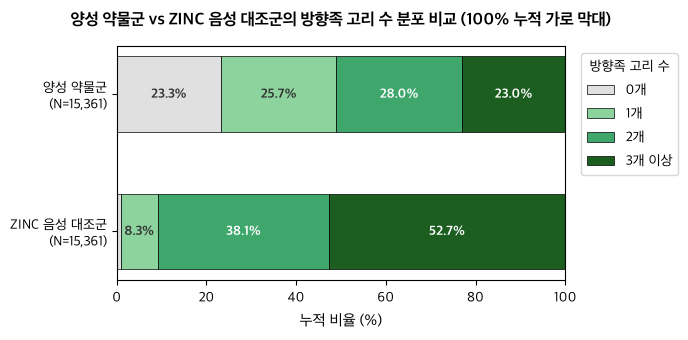

양성 약물군 방향족 고리 수 평균: 1.645개 (중앙값: 2.0개)
ZINC 음성군 방향족 고리 수 평균: 0.9%가 고리 없음, 평균 2.548개


In [ ]:
# Task 2-2. (a)-1 양성 약물군과 ZINC 음성 대조군의 방향족 고리 수 분포 차이를 분석하고 물성 지표 반영 근거 마련
print('[분석] 양성 약물군 vs ZINC 음성 대조군의 방향족 고리 수 분포 비교')
print()
neg_rings = [Descriptors.NumAromaticRings(m) for m in final_neg['mol']]

pos_counts = Counter(pos_df['aromatic_rings'])
neg_counts = Counter(neg_rings)

# 카테고리 정의 (0개, 1개, 2개, 3개 이상)
categories = ['0개', '1개', '2개', '3개 이상']
pos_vals = [
    pos_counts[0] / len(pos_df) * 100,
    pos_counts[1] / len(pos_df) * 100,
    pos_counts[2] / len(pos_df) * 100,
    sum(pos_counts[k] for k in pos_counts if k >= 3) / len(pos_df) * 100
]
neg_vals = [
    neg_counts[0] / len(final_neg) * 100,
    neg_counts[1] / len(final_neg) * 100,
    neg_counts[2] / len(final_neg) * 100,
    sum(neg_counts[k] for k in neg_counts if k >= 3) / len(final_neg) * 100
]

plt.figure(figsize=(7, 3.5))
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

colors = ['#e0e0e0', '#8cd39e', '#3fa66c', '#1b5e20']
y = [f'ZINC 음성 대조군\n(N={len(final_neg):,})', f'양성 약물군\n(N={len(pos_df):,})']

left_pos = np.zeros(2)
for col_idx in range(len(categories)):
    pct_vals = np.array([neg_vals[col_idx], pos_vals[col_idx]])
    bars = plt.barh(y, pct_vals, left=left_pos, label=categories[col_idx], color=colors[col_idx], height=0.55, edgecolor='black', linewidth=0.5)
    left_pos += pct_vals
    
    for row_idx, rect in enumerate(bars):
        width = rect.get_width()
        if width > 2.5:
            plt.text(rect.get_x() + width/2, rect.get_y() + rect.get_height()/2, 
                     f"{width:.1f}%", ha='center', va='center', 
                     fontsize=9.5, fontweight='bold',
                     color='#ffffff' if col_idx >= 2 else '#333333')

plt.xlabel('누적 비율 (%)', fontsize=11)
plt.title('양성 약물군 vs ZINC 음성 대조군의 방향족 고리 수 분포 비교 (100% 누적 가로 막대)', fontsize=12, fontweight='bold', pad=15)
plt.xlim(0, 100)
plt.legend(title='방향족 고리 수', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

print(f"양성 약물군 방향족 고리 수 평균: {np.mean(pos_df['aromatic_rings']):.3f}개 (중앙값: {np.median(pos_df['aromatic_rings'])}개)")
print(f"ZINC 음성군 방향족 고리 수 평균: {neg_rings.count(0)/len(final_neg)*100:.1f}%가 고리 없음, 평균 {np.mean(neg_rings):.3f}개")


[분석] 7대 핵심 물성 분포 및 분위수 경계 검증



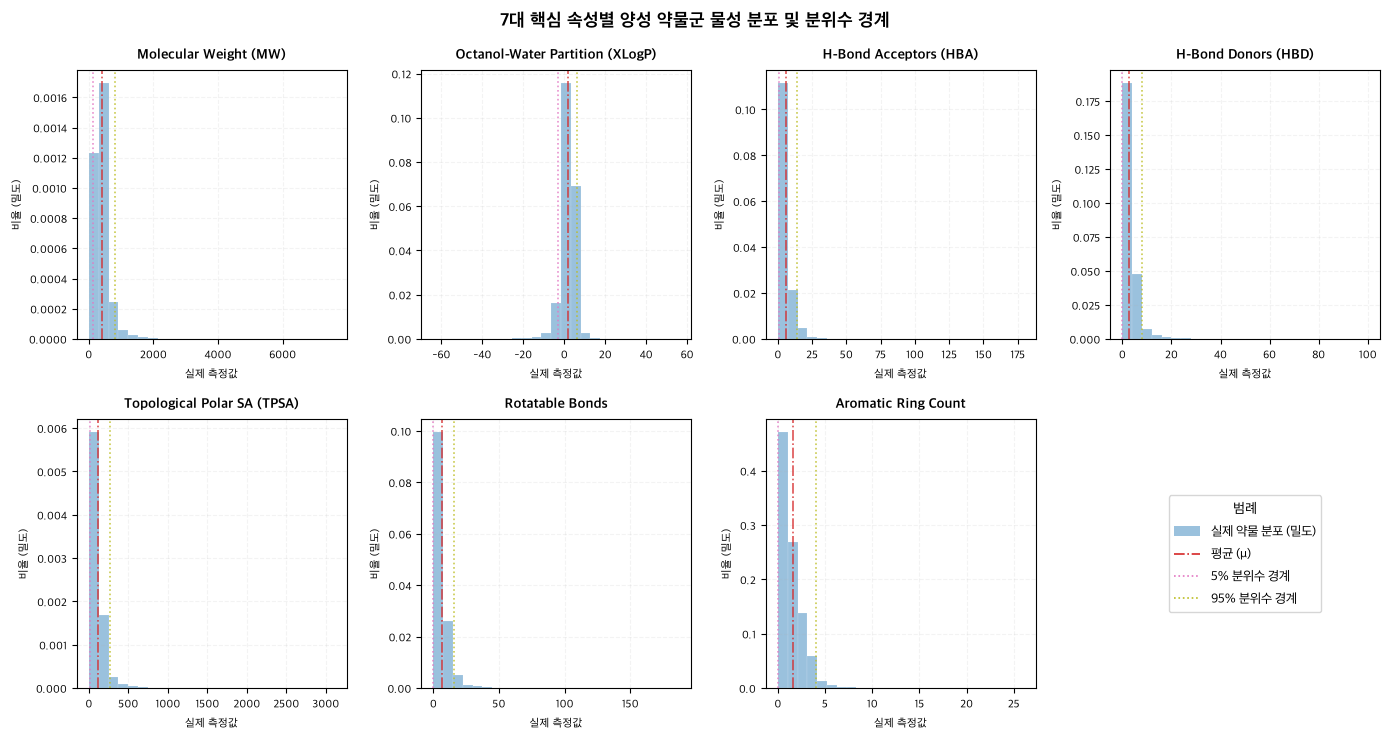

=== 7대 속성 물성 분포 비대칭성 대조 ===
속성                             | 왜도 (Skewness)   | 평균 (μ)          | 5% 분위수          | 95% 분위수
-----------------------------------------------------------------------------------------------
Molecular Weight (MW)          | 8.81            | 409.20          | 146.15          | 822.95
Octanol-Water Partition (XLogP) | -2.52           | 1.85            | -3.21           | 6.02
H-Bond Acceptors (HBA)         | 8.01            | 5.76            | 1.00            | 14.00
H-Bond Donors (HBD)            | 9.71            | 2.88            | 0.00            | 8.00
Topological Polar SA (TPSA)    | 9.28            | 111.98          | 20.23           | 269.90
Rotatable Bonds                | 10.25           | 6.44            | 0.00            | 16.00
Aromatic Ring Count            | 2.22            | 1.64            | 0.00            | 4.00

→ 7대 물성 모두 왜도(Skewness)가 0에서 확연히 벗어나 비대칭형 분포 특성을 띤다.
→ 특히 분자량(MW), polararea(TPSA), rotbonds 등은 강한 양의 왜도(오른쪽 꼬리가 긴 형태)를 나타낸다.


In [35]:
# Task 2-3. (a)-2 약물 물성 분포의 비대칭성(양의 왜도) 및 분위수 경계(5%, 95%) 분포 검증
print('[분석] 7대 핵심 물성 분포 및 분위수 경계 검증')
print()

labels_dict = {
    'mw': 'Molecular Weight (MW)',
    'xlogp': 'Octanol-Water Partition (XLogP)',
    'hbondacc': 'H-Bond Acceptors (HBA)',
    'hbonddonor': 'H-Bond Donors (HBD)',
    'polararea': 'Topological Polar SA (TPSA)',
    'rotbonds': 'Rotatable Bonds',
    'aromatic_rings': 'Aromatic Ring Count'
}

# final_neg에 개별 물성 컬럼이 없으면 생성
for col in PROPERTY_COLUMNS:
    if col not in final_neg.columns:
        final_neg[col] = [prop_funcs[col](m) for m in final_neg['mol']]

# --- 1. 7대 핵심 속성에 대해 실제 분포와 분위수 경계선 시각화 (2x4 그리드) ---
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
axes_flat = axes.flatten()

for i, col in enumerate(PROPERTY_COLUMNS):
    ax1 = axes_flat[i]
    vals = pos_df[col].to_numpy()
    mean_val, sigma_up, sigma_down = stats_asym[col]
    
    # 실제 분포 히스토그램만 깔끔하게 플로팅 (단일 Y축 활용)
    ax1.hist(vals, bins=25, density=True, alpha=0.45, color='#1f77b4', edgecolor='white', linewidth=0.2, label='실제 분포')
    
    ax1.set_title(labels_dict[col], fontsize=10, fontweight='bold', pad=8)
    ax1.set_xlabel('실제 측정값', fontsize=8)
    ax1.set_ylabel('비율 (밀도)', fontsize=8)
    ax1.tick_params(axis='both', labelsize=8)
    ax1.grid(True, linestyle='--', alpha=0.15)
    
    # 분위수 및 평균 경계 수직선
    val_5 = np.percentile(vals, 5)
    val_95 = np.percentile(vals, 95)
    ax1.axvline(mean_val, color='#d62728', linestyle='-.', lw=1.2, alpha=0.8)
    ax1.axvline(val_5, color='#e377c2', linestyle=':', lw=1.2, alpha=0.8)
    ax1.axvline(val_95, color='#bcbd22', linestyle=':', lw=1.2, alpha=0.8)

# 8번째 서브플롯은 범례로 활용
ax_legend = axes_flat[7]
ax_legend.axis('off')
legend_elements = [ 
    Patch(facecolor='#1f77b4', edgecolor='none', alpha=0.45, label='실제 약물 분포 (밀도)'),
    Line2D([0], [0], color='#d62728', lw=1.2, linestyle='-.', label='평균 (μ)'),
    Line2D([0], [0], color='#e377c2', lw=1.2, linestyle=':', label='5% 분위수 경계'),
    Line2D([0], [0], color='#bcbd22', lw=1.2, linestyle=':', label='95% 분위수 경계')
]
ax_legend.legend(handles=legend_elements, loc='center', frameon=True, fontsize=9.5, title='범례', title_fontsize=10)

plt.suptitle('7대 핵심 속성별 양성 약물군 물성 분포 및 분위수 경계', fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# --- 2. 7대 속성 물성 분포 비대칭성 대조 ---
print('=== 7대 속성 물성 분포 비대칭성 대조 ===')
print(f"{'속성':<30} | {'왜도 (Skewness)':<15} | {'평균 (μ)':<15} | {'5% 분위수':<15} | {'95% 분위수'}")
print('-' * 95)

for col in PROPERTY_COLUMNS:
    vals = pos_df[col].to_numpy()
    sk = skew(vals)
    mean_val = np.mean(vals)
    val_5 = np.percentile(vals, 5)
    val_95 = np.percentile(vals, 95)
    print(f"{labels_dict[col]:<30} | {sk:<15.2f} | {mean_val:<15.2f} | {val_5:<15.2f} | {val_95:.2f}")

print()
print('→ 7대 물성 모두 왜도(Skewness)가 0에서 확연히 벗어나 비대칭형 분포 특성을 띤다.')
print('→ 특히 분자량(MW), polararea(TPSA), rotbonds 등은 강한 양의 왜도(오른쪽 꼬리가 긴 형태)를 나타낸다.')


In [32]:
# Task 2-4. (a)-3 분자 속성 범위 및 QED 가중 기하평균 물성 만족도 산출
# (양성군 및 음성 데이터셋에 물리화학 만족도 점수 계산 및 저장)

def get_property_score(mol, stats=stats_asym):
    scores = []
    for col in PROPERTY_COLUMNS:
        val = prop_funcs[col](mol)
        mu, sigma_up, sigma_down = stats[col]
        d = max(desirability_asym(val, mu, sigma_up, sigma_down), 1e-9)
        scores.append(d)
    return float(np.prod(scores) ** (1.0 / len(PROPERTY_COLUMNS)))

pos_df['property_score'] = [get_property_score(m) for m in pos_df['mol']]
final_neg['property_score'] = [get_property_score(m) for m in final_neg['mol']]

print("7대 물성 만족도 점수(Property Score) 계산 완료")

7대 물성 만족도 점수(Property Score) 계산 완료


In [ ]:
# Task 2-5. (b)-1 골격 및 잔기 마이닝 기준 선정 근거 분석
# (1회성 노이즈(Singleton)를 배제하고 목표 커버리지를 채우는 동적 개수 계산)
print('=== [분석] 약물 고유 골격(Scaffold) 및 고유 잔기(Residue) 마이닝 기준 선정 근거 ===')
print()


# 1. 골격(Scaffold) 분석
pos_scaffolds = []
for mol in pos_df['mol']:
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    scf_smi = Chem.MolToSmiles(scf)
    if scf_smi:
        pos_scaffolds.append(scf_smi)

scf_counts = Counter(pos_scaffolds)
sorted_scfs = scf_counts.most_common()
total_scf = len(pos_scaffolds)
singletons_scf = sum(1 for s, f in scf_counts.items() if f == 1)

# 1회 출현(Singleton) 제외 유효 골격군 기준 동적 결정
filtered_scfs = {s: f for s, f in scf_counts.items() if f > 1}
sorted_filtered_scfs = sorted(filtered_scfs.items(), key=lambda x: x[1], reverse=True)
total_filtered_scf_freq = sum(filtered_scfs.values())

scaffold_target_coverage = 0.60
cumulative_scf = 0
selected_scaffold_count = 0
for i, (_, freq) in enumerate(sorted_filtered_scfs, 1):
    cumulative_scf += freq
    if cumulative_scf / total_filtered_scf_freq >= scaffold_target_coverage:
        selected_scaffold_count = i
        break
if selected_scaffold_count == 0:
    selected_scaffold_count = len(sorted_filtered_scfs)
scf_cov_actual = cumulative_scf / total_filtered_scf_freq

print(f"▶ 골격(Scaffold) 함유 양성 분자 수: {total_scf}개 / 고유 골격 종류: {len(scf_counts)}종")
print(f"  - 1회만 출현한 희귀 골격 (Singleton): {singletons_scf}종 ({singletons_scf/len(scf_counts)*100:.1f}%)")
print(f"  - 1회 출현 제외 유효 골격 {scaffold_target_coverage*100:.0f}% 커버리지를 만족하는 개수: {selected_scaffold_count}종")
print(f"  - 상위 {selected_scaffold_count}종 골격의 유효 커버리지: {scf_cov_actual*100:.1f}%")
print("  - 분석: 골격은 1회성 노이즈(과적합 요인)를 배제한 후, 변별력 저하 및 점수 쏠림을 막기 위해")
print("    60%의 보수적인 커버리지를 적용하여 대표 핵심 구조들을 동적으로 선별한다.")
print()

# 2. 잔기(Residue) 분석
pos_residues = []
for mol in pos_df['mol']:
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    if sidechains is not None:
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f'[{n}*]', '[*]')
            pos_residues.append(key)

res_counts = Counter(pos_residues)
sorted_res = res_counts.most_common()
total_res = len(pos_residues)
singletons_res = sum(1 for s, f in res_counts.items() if f == 1)

# 1회 출현(Singleton) 제외 유효 잔기군 기준 동적 결정
filtered_res = {r: f for r, f in res_counts.items() if f > 1}
sorted_filtered_res = sorted(filtered_res.items(), key=lambda x: x[1], reverse=True)
total_filtered_res_freq = sum(filtered_res.values())

residue_target_coverage = 0.70
cumulative_res = 0
selected_residue_count = 0
for i, (_, freq) in enumerate(sorted_filtered_res, 1):
    cumulative_res += freq
    if cumulative_res / total_filtered_res_freq >= residue_target_coverage:
        selected_residue_count = i
        break
if selected_residue_count == 0:
    selected_residue_count = len(sorted_filtered_res)
res_cov_actual = cumulative_res / total_filtered_res_freq

print(f"▶ 곁사슬 잔기(Residue) 총 파편 수: {total_res}개 / 고유 잔기 종류: {len(res_counts)}종")
print(f"  - 1회만 출현한 희귀 잔기 (Singleton): {singletons_res}종 ({singletons_res/len(res_counts)*100:.1f}%)")
print(f"  - 1회 출현 제외 유효 잔기 {residue_target_coverage*100:.0f}% 커버리지를 만족하는 개수: {selected_residue_count}종")
print(f"  - 상위 {selected_residue_count}종 잔기의 유효 커버리지: {res_cov_actual*100:.1f}%")
print("  - 분석: 잔기는 몇몇 보편적인 핵심 구조에 분포가 많이 집중되어 있어, 70%의 높은 커버리지를 만족하는")
print("    소수(약 21종)의 핵심 치환기만으로 효율적으로 전체 특징을 대변할 수 있다.")


=== [분석] 약물 고유 골격(Scaffold) 및 고유 잔기(Residue) 마이닝 기준 선정 근거 ===

▶ 골격(Scaffold) 함유 양성 분자 수: 13865개 / 고유 골격 종류: 6368종
  - 1회만 출현한 희귀 골격 (Singleton): 4719종 (74.1%)
  - 1회 출현 제외 유효 골격 60% 커버리지를 만족하는 개수: 272종
  - 상위 272종 골격의 유효 커버리지: 60.0%
  - 분석: 골격은 1회성 노이즈(과적합 요인)를 배제한 후, 변별력 저하 및 점수 쏠림을 막기 위해
    60%의 보수적인 커버리지를 적용하여 대표 핵심 구조들을 동적으로 선별한다.

▶ 곁사슬 잔기(Residue) 총 파편 수: 52350개 / 고유 잔기 종류: 3423종
  - 1회만 출현한 희귀 잔기 (Singleton): 1975종 (57.7%)
  - 1회 출현 제외 유효 잔기 70% 커버리지를 만족하는 개수: 21종
  - 상위 21종 잔기의 유효 커버리지: 70.1%
  - 분석: 잔기는 몇몇 보편적인 핵심 구조에 분포가 많이 집중되어 있어, 70%의 높은 커버리지를 만족하는
    소수(약 21종)의 핵심 치환기만으로 효율적으로 전체 특징을 대변할 수 있다.


In [36]:
# Task 2-6. (b)-2 약물 고유 골격 및 고유 잔기(SMARTS 패턴) 마이닝

N_pos = len(pos_df)
N_neg = len(final_neg)

# 1. 양성군 단독 빈도 기반 골격(Scaffold) 마이닝
def mine_scaffold_smarts_positive_only(pos_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi: pos_counts[scf_smi] += 1
    
    # 1회 출현 골격(Singleton) 제외
    filtered = {s: c for s, c in pos_counts.items() if c > 1}
    sorted_scf = sorted(filtered.items(), key=lambda x: x[1], reverse=True)
    top_n = len(sorted_scf) if top_n is None else top_n
    
    patterns = []
    weights = []
    for scf_smi, cnt in sorted_scf[:top_n]:
        try:
            scf_mol = Chem.MolFromSmiles(scf_smi)
            if scf_mol is None: continue
            smarts = Chem.MolToSmarts(scf_mol)
            pattern = Chem.MolFromSmarts(smarts)
            if pattern is not None:
                patterns.append(pattern)
                weights.append(float(cnt))  # 가중치 = 양성군 출현 횟수
        except:
            continue
    return patterns, weights

# 2. 양성군 단독 빈도 기반 잔기(Residue) 마이닝
def mine_residue_smarts_positive_only(pos_df, top_n=None):
    pos_counts = Counter()
    for mol in pos_df['mol']:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None: continue
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f'[{n}*]', '[*]')
            pos_counts[key] += 1
    
    # 1회 출현 잔기(Singleton) 제외
    filtered = {r: c for r, c in pos_counts.items() if c > 1}
    sorted_res = sorted(filtered.items(), key=lambda x: x[1], reverse=True)
    top_n = len(sorted_res) if top_n is None else top_n
    
    patterns = []
    weights = []
    for res_smi, cnt in sorted_res[:top_n]:
        try:
            pattern = Chem.MolFromSmarts(res_smi)
            if pattern is not None:
                patterns.append(pattern)
                weights.append(float(cnt))  # 가중치 = 양성군 출현 횟수
        except:
            continue
    return patterns, weights

SCAFFOLD_TOP_N = globals().get('selected_scaffold_count', 272)
RESIDUE_TOP_N  = globals().get('selected_residue_count', 21)

SCAFFOLD_PATTERNS_BASE, SCAFFOLD_WEIGHTS_BASE = mine_scaffold_smarts_positive_only(pos_df, top_n=SCAFFOLD_TOP_N)
RESIDUE_PATTERNS_BASE,  RESIDUE_WEIGHTS_BASE  = mine_residue_smarts_positive_only(pos_df, top_n=RESIDUE_TOP_N)

# 3. 양성군 빈도 누적 방식 구조 스코어링 함수 (정규화 기준 = 전체 가중치 합)
_scaf_max_base = sum(SCAFFOLD_WEIGHTS_BASE) if SCAFFOLD_WEIGHTS_BASE else 1.0
_res_max_base  = sum(RESIDUE_WEIGHTS_BASE)  if RESIDUE_WEIGHTS_BASE  else 1.0

def get_scaffold_score_only_base(mol, patterns=SCAFFOLD_PATTERNS_BASE, weights=SCAFFOLD_WEIGHTS_BASE, max_w=_scaf_max_base):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    if scf is None: return 0.0
    score = sum(w for p, w in zip(patterns, weights) if scf.HasSubstructMatch(p))
    return min(1.0, score / max_w)

def get_residue_score_only_base(mol, patterns=RESIDUE_PATTERNS_BASE, weights=RESIDUE_WEIGHTS_BASE, max_w=_res_max_base):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    tgt = sidechains if sidechains is not None else mol
    score = sum(w for p, w in zip(patterns, weights) if tgt.HasSubstructMatch(p))
    return min(1.0, score / max_w)

# 베이스라인 구조 점수 캐싱
pos_scaf_arr = np.array([get_scaffold_score_only_base(m) for m in pos_df['mol']])
neg_scaf_arr = np.array([get_scaffold_score_only_base(m) for m in final_neg['mol']])

pos_res_arr = np.array([get_residue_score_only_base(m) for m in pos_df['mol']])
neg_res_arr = np.array([get_residue_score_only_base(m) for m in final_neg['mol']])

print(f"베이스라인 구조 마이닝 및 성분(골격 {len(SCAFFOLD_PATTERNS_BASE)}종, 잔기 {len(RESIDUE_PATTERNS_BASE)}종) 캐싱 완료")


베이스라인 구조 마이닝 및 성분(골격 272종, 잔기 21종) 캐싱 완료


In [ ]:
# Task 2-7. 점수 분포 확인 함수

def plot_pure_components(pos_prop, neg_prop, pos_scaf_arr, neg_scaf_arr, pos_res_arr, neg_res_arr, save_filename='dpure_components_distribution.png'):
    """
    3가지 단일 특성(Property, Scaffold, Residue)의 양성/음성 점수 분포를 1x3 서브플롯으로 비교 시각화하는 함수.
    """
    # 1. 폰트 설정
    available_fonts = {f.name for f in fm.fontManager.ttflist}
    if platform.system() == 'Windows':
        font_candidates = ['Apple SD Gothic Neo', 'Arial Unicode MS', 'Noto Sans CJK KR', 'NanumGothic', 'DejaVu Sans']
    elif platform.system() == 'Darwin':
        font_candidates = ['Arial Unicode MS', 'AppleGothic', 'Noto Sans CJK KR', 'NanumGothic', 'DejaVu Sans']
    else:
        font_candidates = ['Noto Sans CJK KR', 'NanumGothic', 'Arial Unicode MS', 'DejaVu Sans']
    selected_font = next((name for name in font_candidates if name in available_fonts), None)
    plt.rcParams['font.family'] = selected_font if selected_font else 'sans-serif'
    plt.rcParams['axes.unicode_minus'] = False

    # 2. 3가지 단일 특성 점수 매핑
    pure_scores = [
        ("1. 물리화학적 특성만 (Property 100%)", pos_prop, neg_prop),
        ("2. 골격 구조만 (Scaffold 100%)", pos_scaf_arr, neg_scaf_arr),
        ("3. 잔기 구조만 (Residue 100%)", pos_res_arr, neg_res_arr)
    ]

    # 3. 1x3 서브플롯 생성
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)
    c_pos, c_neg = '#2563EB', '#EF4444' # 파란색(양성), 빨간색(음성)

    # 내부 함수: 간단한 KDE (커널 밀도 추정)
    def simple_kde(data, bins=200, bw=0.03):
        x = np.linspace(0, 1, bins)
        kde = np.zeros_like(x)
        for d in data:
            kde += np.exp(-0.5 * ((x - d) / bw) ** 2)
        if len(data) > 0:
            kde /= (len(data) * bw * np.sqrt(2 * np.pi))
        return x, kde

    # 4. 각 특성별로 히스토그램 및 KDE 시각화
    for i, (title, pos_scores, neg_scores) in enumerate(pure_scores):
        ax = axes[i]
        
        # 히스토그램 (배경에 옅게)
        ax.hist(pos_scores, bins=30, alpha=0.25, density=True, color=c_pos)
        ax.hist(neg_scores, bins=30, alpha=0.25, density=True, color=c_neg)
        
        # KDE 선 (메인 트렌드)
        x_pos, kde_pos = simple_kde(pos_scores)
        x_neg, kde_neg = simple_kde(neg_scores)
        ax.plot(x_pos, kde_pos, color=c_pos, linewidth=2, label=f'Drugs (N={len(pos_scores)})')
        ax.plot(x_neg, kde_neg, color=c_neg, linewidth=2, label=f'ZINC DB (N={len(neg_scores)})')
        
        # 꾸미기
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Pesticide-like Score', fontsize=10)
        if i == 0:
            ax.set_ylabel('Density', fontsize=10)
        ax.set_xlim(0, 1)
        ax.grid(True, linestyle=':', alpha=0.5)
        ax.legend(fontsize=8, frameon=True, facecolor='white', edgecolor='none')

    plt.suptitle('🔍 각 특성별 단독 판별력(Score Distribution) 비교', fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    
    # 저장 및 출력
    if save_filename:
        plt.savefig(save_filename, dpi=200, bbox_inches='tight')
    plt.show()

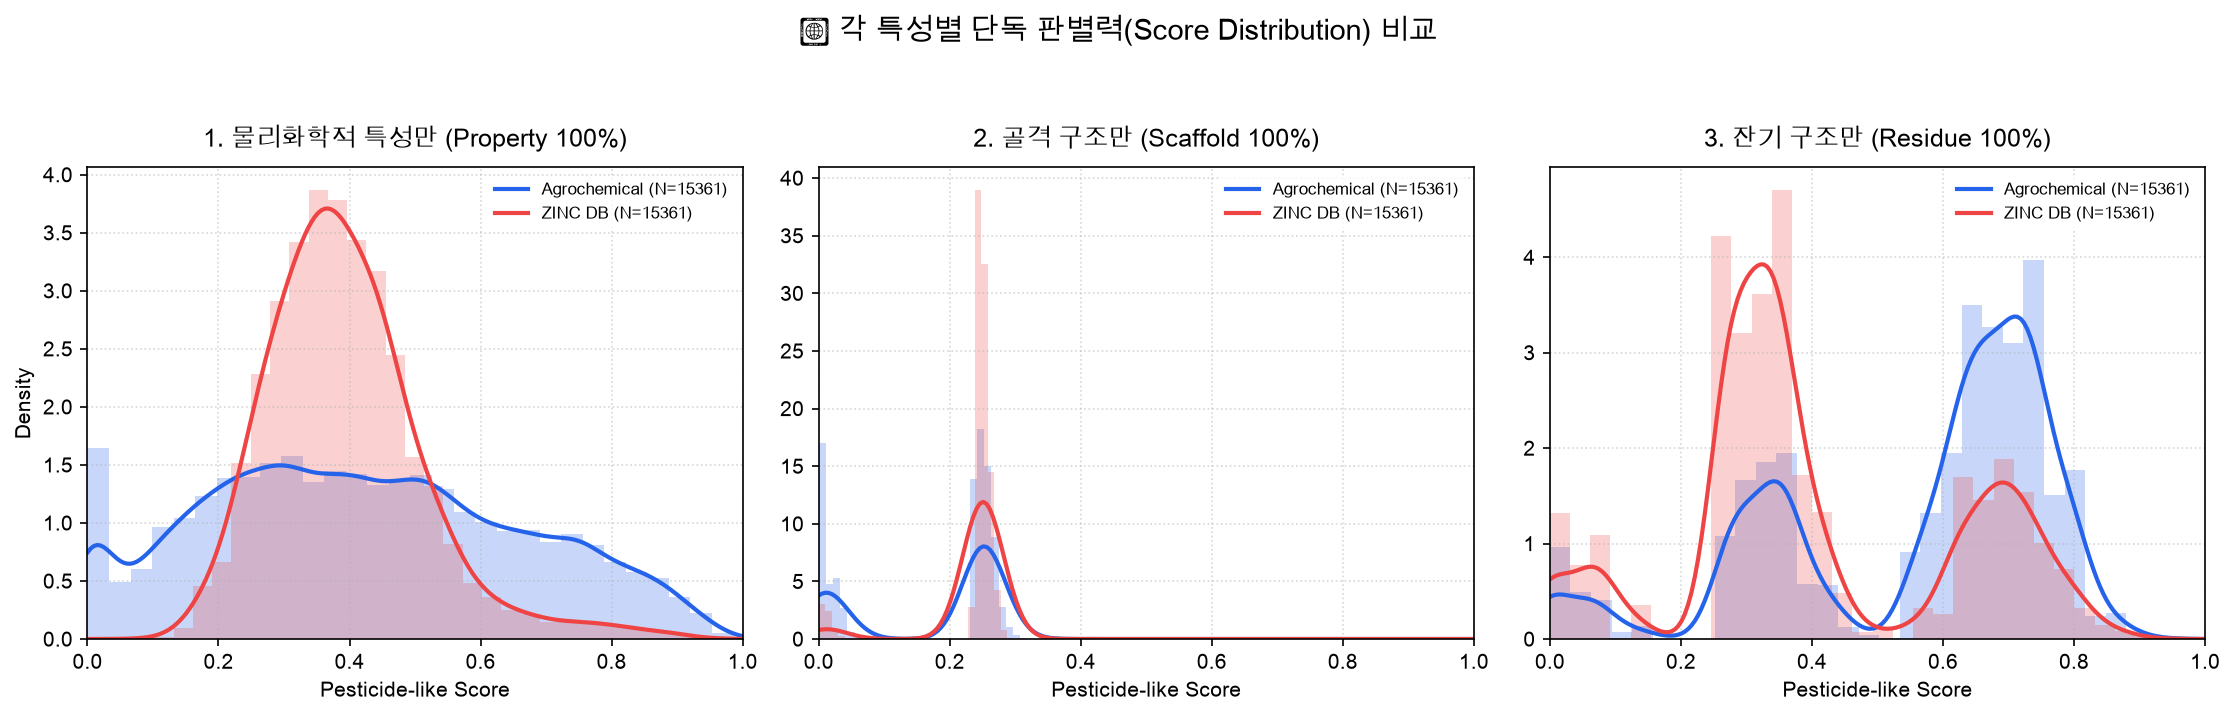

In [ ]:
# Task 2-8. 베이스라인 물성 및 구조 점수를 로드하여 1차 단독 판별력 시각화
pos_prop = pos_df['property_score'].to_numpy()
neg_prop = final_neg['property_score'].to_numpy()

plot_pure_components(
    pos_prop=pos_prop, 
    neg_prop=neg_prop, 
    pos_scaf_arr=pos_scaf_arr, 
    neg_scaf_arr=neg_scaf_arr, 
    pos_res_arr=pos_res_arr, 
    neg_res_arr=neg_res_arr,
    save_filename='dpure_components_distribution.png'
)

### **3. 단일 특성(Property vs Scaffold vs Residue) 개별 분포 분석 및 기존 스코어링의 한계점**

#### **개별 특성 단독 판별력을 확인하게 된 배경**
- 기존 비대칭 가우시안 만족도와 단순 구조 개수 누적 가중치 방식을 통합하여 다차원 그리드 서치(가중치 최적화)를 수행하였을 때, 다음과 같은 이상 징후가 관찰되었다.
  1. **물성 가중치의 0 수렴/역전 현상**: 종합 스코어를 최적화하는 과정에서 물리화학적 특성 가중치($w_p$)가 비정상적으로 0에 가깝게 하락하거나 완전히 배제되는 경향이 나타났다.
  2. **스코어 분포의 다중 이산 봉우리 발생**: 최종 점수 분포를 시각화했을 때 매끄러운 단일 곡선이 아니라, 마치 빗 모양처럼 불연속적이고 이산적인 봉우리(Peak)가 여러 개 생기는 현상이 목격되었다.
- 이러한 현상의 근본 원인을 규명하기 위해, 각 특성(물리화학적 특성, 골격 구조, 잔기 구조)이 단독 가중치 100%일 때 양성군(약물)과 음성군(ZINC DB) 간에 어떠한 스코어 분포를 형성하며 판별력을 지니는지 개별적으로 비교 분석을 수행하였다.


#### **베이스라인 시각화 분석 결과 및 문제 진단**
- **1. 물리화학적 특성 단독 (Property 100%)**:
  - **문제점**: 양성군과 음성군(ZINC DB)의 스코어 밀도 분포가 상당 부분 중첩되어 변별력이 매우 낮다.
  - **원인**: ZINC DB는 신약 개발 후보 물질 위주로 구성되어 있어, 특정 물리화학적 영역(예: 분자량 300~450, 중간 정도의 LogP)에 매우 뾰족하고 조밀하게 뭉쳐 있다. 비대칭 가우시안 함수는 양성군의 분포(평균)를 기준으로 구축되었기 때문에, 이 좁은 영역에 고밀도로 밀집한 ZINC DB 분자들이 오히려 약물(양성)보다 더 높은 만족도 점수를 부여받는 스코어 역전 문제가 발생한다. 이에 따라 최적화 알고리즘이 음성군을 분리하기 위해 물성 가중치를 강제로 0으로 깎아버리는 현상이 발생한다.
- **2. 골격 구조 단독 (Scaffold 100%)**:
  - **문제점**: 음성군(ZINC DB)의 스코어 분포가 우측(높은 점수 영역)으로 치우치며 점수 인플레이션이 심각하다.
  - **원인**: 마이닝된 골격의 매칭 개수를 단순 누적하여 합산하는 방식에서는, 벤젠 고리나 피리딘 고리처럼 유기화합물에 대단히 흔하게 존재하는 보편적인 고리 구조가 매칭될 때마다 점수가 계속해서 누적된다. ZINC DB 분자들도 이러한 흔한 고리를 기본적으로 장착하고 있어, 약물 특이적 골격이 아님에도 불구하고 높은 점수를 획득하게 된다.
- **3. 잔기 구조 단독 (Residue 100%)**:
  - **문제점**: 골격과 동일하게 ZINC DB가 고득점 영역을 쉽게 침범하며, 스코어 값 자체가 이산적인(불연속적인) 몇 개의 막대(Peak) 형태로만 나뉘어 분포한다.
  - **원인**: 곁사슬 잔기 역시 두 집단 간에 공유되는 보편적인 지방족/친수성 파편이 많아 단순 개수 누적 시 변별력이 저하된다. 또한, 구조 점수가 정수 형태의 매칭 개수(0개, 1개, 2개 등)에 비례하여 비연속적으로 정규화되기 때문에, 점수 분포 상에 여러 개의 이산적 봉우리가 발생하는 주요 원인이 된다.


물성 (Property)                | 데이터 그룹       | 평균 (Mean)  | 표준편차(Std)  | 왜도(Skewness)
-------------------------------------------------------------------------------------
Molecular Weight (MW)        | 약물 (Pos)     | 409.20     | 355.34     | 8.81      
                             | ZINC (Neg)   | 377.79     | 35.47      | -2.88     
-------------------------------------------------------------------------------------
Octanol-Water Partition (X   | 약물 (Pos)     | 1.85       | 3.52       | -2.52     
                             | ZINC (Neg)   | 4.90       | 1.13       | -2.93     
-------------------------------------------------------------------------------------
H-Bond Acceptors (HBA)       | 약물 (Pos)     | 5.76       | 6.06       | 8.01      
                             | ZINC (Neg)   | 3.45       | 1.28       | 0.52      
-------------------------------------------------------------------------------------
H-Bond Donors (HBD)          | 약물 (Pos)     | 2.88       | 4.75       | 9

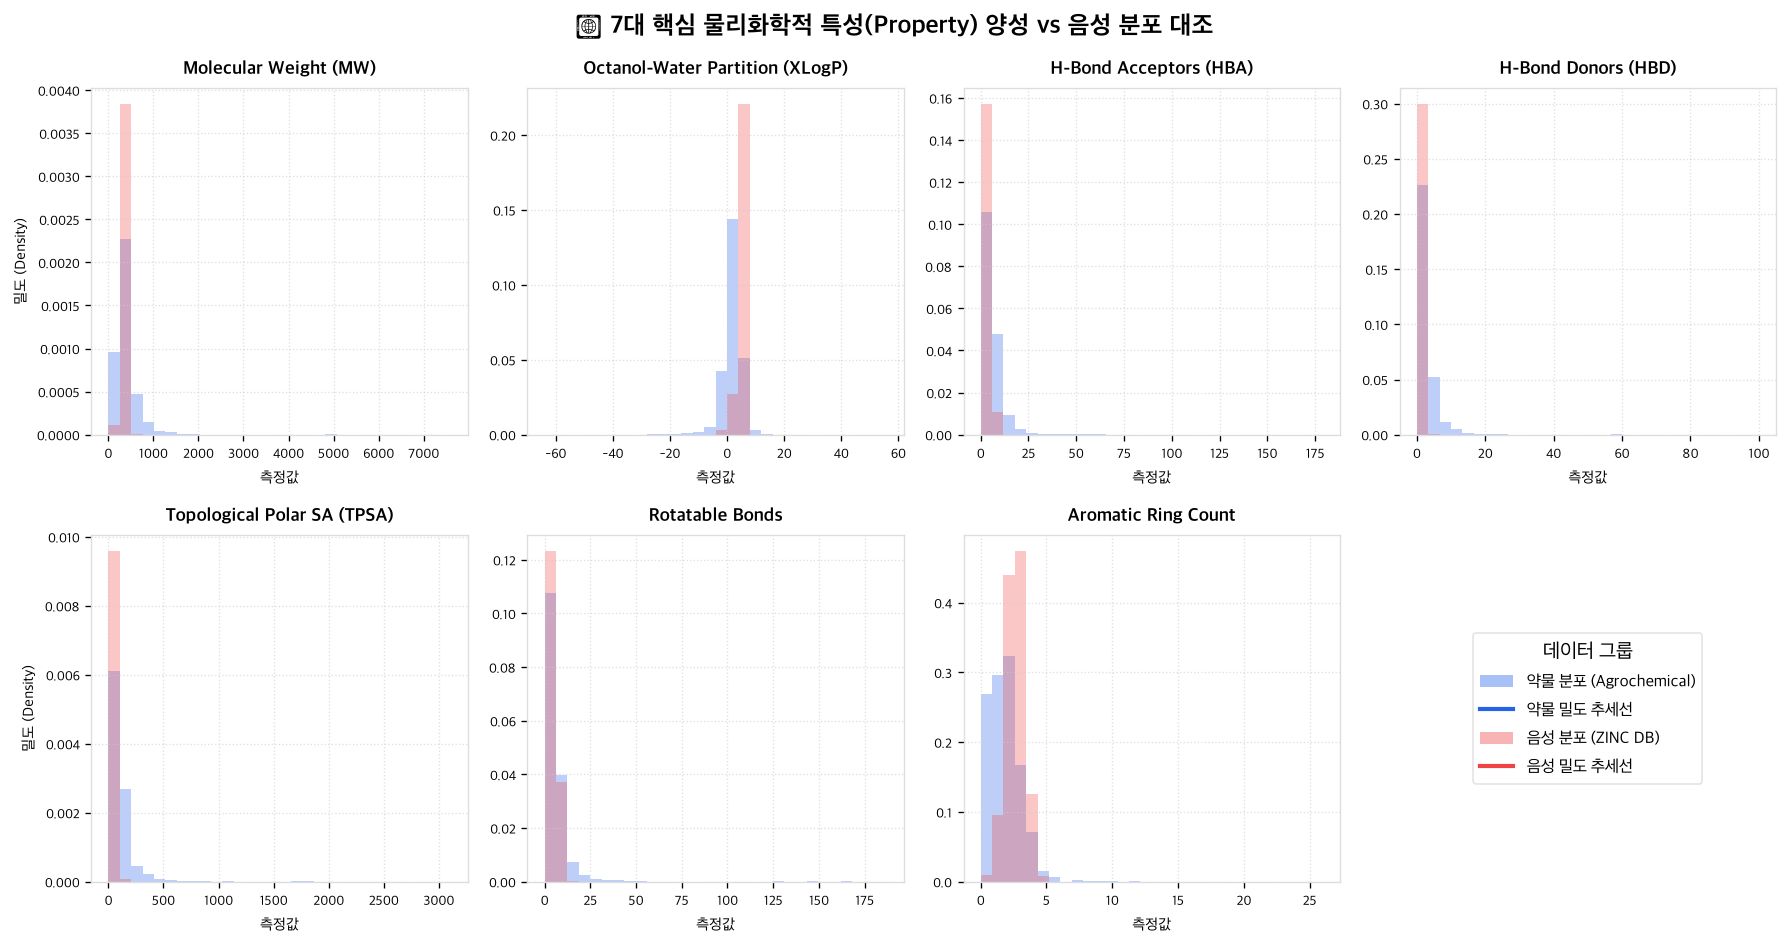

In [ ]:
# Task 2-9. 변수가 정의되어 있지 않을 경우를 대비한 7대 속성 리스트

# =====================================================================
# 1. 7대 핵심 물리화학적 특성(Property) 통계값 대조 출력
# =====================================================================
print("=" * 85)
print(f"{'물성 (Property)':<28} | {'데이터 그룹':<12} | {'평균 (Mean)':<10} | {'표준편차(Std)':<10} | {'왜도(Skewness)':<10}")
print("-" * 85)

for col in PROPERTY_COLUMNS:
    vals_pos = pos_df[col].dropna().to_numpy()
    vals_neg = final_neg[col].dropna().to_numpy()
    
    # 통계값 계산
    p_mean, p_std, p_skew = np.mean(vals_pos), np.std(vals_pos), skew(vals_pos)
    n_mean, n_std, n_skew = np.mean(vals_neg), np.std(vals_neg), skew(vals_neg)
    
    prop_name = labels_dict[col][:26] # 표 정렬을 위해 이름 길이 제한
    print(f"{prop_name:<28} | {'약물 (Pos)':<12} | {p_mean:<10.2f} | {p_std:<10.2f} | {p_skew:<10.2f}")
    print(f"{'':<28} | {'ZINC (Neg)':<12} | {n_mean:<10.2f} | {n_std:<10.2f} | {n_skew:<10.2f}")
    print("-" * 85)
print("\n")


# =====================================================================
# 2. 양성 vs 음성 분포 대조 시각화
# =====================================================================
# 폰트 설정 (기존 환경 유지)
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 색상 테마
c_pos = '#2563EB'  # 파란색 (약물 - 양성)
c_neg = '#EF4444'  # 빨간색 (ZINC DB - 음성)

fig, axes = plt.subplots(2, 4, figsize=(15, 8), dpi=120)
axes_flat = axes.flatten()

for i, col in enumerate(PROPERTY_COLUMNS):
    ax = axes_flat[i]
    
    # 데이터 추출 (결측치 제외)
    vals_pos = pos_df[col].dropna().to_numpy()
    vals_neg = final_neg[col].dropna().to_numpy()
    
    # 1. 히스토그램 (투명도를 주어 겹치게 표현)
    all_vals = np.concatenate([vals_pos, vals_neg])
    bins = np.histogram_bin_edges(all_vals, bins=30)
    
    ax.hist(vals_pos, bins=bins, density=True, alpha=0.3, color=c_pos, edgecolor='none')
    ax.hist(vals_neg, bins=bins, density=True, alpha=0.3, color=c_neg, edgecolor='none')
    
    # # 2. KDE 곡선 (부드러운 밀도 추정 선)
    # try:
    #     kde_pos = gaussian_kde(vals_pos)
    #     kde_neg = gaussian_kde(vals_neg)
        
    #     x_grid = np.linspace(all_vals.min(), all_vals.max(), 200)
    #     ax.plot(x_grid, kde_pos(x_grid), color=c_pos, lw=2.5)
    #     ax.plot(x_grid, kde_neg(x_grid), color=c_neg, lw=2.5)
    # except Exception:
    #     pass

    # 서브플롯 꾸미기
    ax.set_title(labels_dict[col], fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('측정값', fontsize=9)
    if i == 0 or i == 4:
        ax.set_ylabel('밀도 (Density)', fontsize=9)
    
    ax.tick_params(axis='both', labelsize=8)
    ax.grid(True, linestyle=':', alpha=0.6, color='#CCCCCC')
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')

# 8번째 서브플롯: 통합 범례 생성
ax_legend = axes_flat[7]
ax_legend.axis('off')

legend_elements = [ 
    Patch(facecolor=c_pos, alpha=0.4, label='약물 분포 (Drugs)'),
    Line2D([0], [0], color=c_pos, lw=2.5, label='약물 밀도 추세선'),
    Patch(facecolor=c_neg, alpha=0.4, label='음성 분포 (ZINC DB)'),
    Line2D([0], [0], color=c_neg, lw=2.5, label='음성 밀도 추세선')
]
ax_legend.legend(handles=legend_elements, loc='center', frameon=True, facecolor='white', 
                 edgecolor='#DDDDDD', fontsize=10, title='데이터 그룹', title_fontsize=12)

plt.suptitle('📊 7대 핵심 물리화학적 특성(Property) 양성 vs 음성 분포 대조', fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('property_distribution_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### **4. 약물 vs ZINC: 7대 물성(Property) 분포 비교 결과 해석**

- 위 코드는 `PubChem_Drugs` 양성 데이터와 `ZINC` 음성 데이터를 대상으로 7대 핵심 물리화학적 특성의 분포를 겹쳐 시각화했다.
- 각 속성별 히스토그램은 양성(약물)과 음성(ZINC)의 밀도 분포 차이를 비교하여, 약물 특성이 두드러지는 구간을 직관적으로 확인할 수 있도록 한다.
- 이 시각화는 이후 경험적 PPV 기반 물성 모델과 구조 기반 스코어링 전략을 설계하기 위한 기초 단계로 활용된다.
- 생성된 그림은 `property_distribution_comparison.png`로 저장된다.


In [62]:
# ==============================================================================
# Task 2-10. (a) 경험적 PPV 물성 모델 구축
# ==============================================================================
print(
    "[연산] 1. 히스토그램 기반 경험적 확률 비율(PPV) 물성 모델 구축 시작..."
)

# 1-1. 핵심 물성 정의
SELECTED_PROPS = ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea', 'aromatic_rings']

# 1-2. 각 물성별 히스토그램 구간(Bin) 경계 및 집단별 확률 밀도(Density) 계산
hist_models = {"pos": {}, "neg": {}, "bins": {}}
NUM_BINS = 30  # 전체 데이터 범위를 30개의 막대 구간으로 분할

for col in SELECTED_PROPS:
    vals_pos = pos_df[col].dropna().to_numpy()
    vals_neg = final_neg[col].dropna().to_numpy()

    # 양성과 음성 데이터 공통 최소~최대 구간 설정
    min_val = min(vals_pos.min(), vals_neg.min())
    max_val = max(vals_pos.max(), vals_neg.max())
    bins = np.linspace(min_val, max_val, NUM_BINS + 1)
    hist_models["bins"][col] = bins

    # 구간별 밀도(Density) 산출: 해당 구간에 데이터가 빽빽하게 몰려있을수록 높은 밀도값 반환
    hist_pos, _ = np.histogram(vals_pos, bins=bins, density=True)
    hist_neg, _ = np.histogram(vals_neg, bins=bins, density=True)

    hist_models["pos"][col] = hist_pos
    hist_models["neg"][col] = hist_neg


# 1-3. 경험적 PPV 물성 스코어 함수: 특정 물성값이 주어졌을 때 약물일 확률 산출
def get_property_score_hist(mol):
    try:
        props = {
            "mw": Descriptors.MolWt(mol),
            "xlogp": Descriptors.MolLogP(mol),
            "hbondacc": Descriptors.NumHAcceptors(mol),
            "hbonddonor": Descriptors.NumHDonors(mol),
            "polararea": Descriptors.TPSA(mol),
            "aromatic_rings": rdMolDescriptors.CalcNumAromaticRings(mol),
        }
    except Exception:
        return 0.0  # 손상된 분자는 0점 처리

    total_score = 0.0
    for col in SELECTED_PROPS:
        val = props[col]
        bins = hist_models["bins"][col]

        # 입력된 분자의 물성값이 30개 막대 중 몇 번째 막대에 속하는지 인덱스 탐색
        bin_idx = np.digitize(val, bins) - 1
        bin_idx = max(0, min(bin_idx, NUM_BINS - 1))  # 인덱스 범위 초과 방지

        p_pos = hist_models["pos"][col][bin_idx]
        p_neg = hist_models["neg"][col][bin_idx]

        # 베이즈 확률(PPV) 수식: P(Pos) / [ P(Pos) + P(Neg) ]
        # (데이터가 아예 없는 빈 구간을 지날 때 0으로 나누어지는 에러를 방지하기 위해 분모 하한선 1e-10 설정)
        if (p_pos + p_neg) > 1e-10:
            score = p_pos / (p_pos + p_neg)
        else:
            score = 0.0
        total_score += score

    # 4개 속성 PPV 점수의 평균값을 최종 물성 점수로 반환 (0.0 ~ 1.0)
    return total_score / len(SELECTED_PROPS)

[연산] 1. 히스토그램 기반 경험적 확률 비율(PPV) 물성 모델 구축 시작...


In [63]:
# ==============================================================================
# 2-11 (b) PPV 기반 골격/잔기 족보 마이닝 & 'Max PPV' 기반 구조 스코어링 적용
# ==============================================================================
print(
    "\n[연산] 2. 양성 특이적(Pos-Specific) 골격 및 잔기 마이닝 시작..."
)
N_pos, N_neg = len(pos_df), len(final_neg)


# ==============================================================================
# 2-1. 골격(Scaffold) 족보 마이닝 : 'SMARTS 유연 탐색' 기반 핵심 뼈대 추출
# ==============================================================================
# [설계 의도] 
# 1. 집계 단계: 정확한 카운팅을 위해 분자의 뼈대를 정규 smiles 문자열로 추출하여 빈도를 계산한다.
# 2. 변환 단계: 실제 스코어링 시에는 치환기가 붙은 방향이나 위치가 조금씩 달라도 유연하게 포획할 수 있도록
#    smiles를 SMARTS 패턴 객체로 변환하여 족보에 저장한다. (양성군 커버리지 확보 목적)

def mine_scaffold_smarts_specific_ppv(pos_df, neg_df, top_n=272):
    pos_counts = Counter()
    for mol in pos_df["mol"]:
        # Bemis-Murcko 알고리즘을 통해 곁가지를 모두 쳐낸 순수 중심 고리 골격만 추출
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi:
            pos_counts[scf_smi] += 1

    neg_counts = Counter()
    for mol in neg_df["mol"]:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        scf_smi = Chem.MolToSmiles(scf)
        if scf_smi:
            neg_counts[scf_smi] += 1

    # 1회 출현(Singleton) 패턴은 우연에 의한 노이즈일 확률이 높으므로 족보 후보에서 즉시 제외
    filtered_pos = {s: c for s, c in pos_counts.items() if c > 1}

    specific_scores = {}
    for scf_smi, pos_cnt in filtered_pos.items():
        p_pos = pos_cnt / N_pos
        p_neg = neg_counts.get(scf_smi, 0) / N_neg
        # (양성군 출현율 - 음성군 출현율)을 기준으로 삼아 약물에만 집중적으로 나타나는 특이적 뼈대 선별
        specific_scores[scf_smi] = (p_pos - p_neg, p_pos, p_neg)

    sorted_scf = sorted(
        specific_scores.items(), key=lambda x: x[1][0], reverse=True
    )

    patterns, weights = [], []
    for scf_smi, (diff, p_pos, p_neg) in sorted_scf[:top_n]:
        # 양성군보다 음성군(ZINC)에서 더 자주 관측되는 뼈대는 스코어링의 변별력을 해치므로 즉시 차단
        if diff <= 0:
            break  
            
        try:
            scf_mol = Chem.MolFromSmiles(scf_smi)
            if scf_mol is None:
                continue
                
            # 정규 smiles를 유연한 탐색이 가능한 SMARTS 문자열 및 패턴 객체로 컴파일
            pattern = Chem.MolFromSmarts(Chem.MolToSmarts(scf_mol))
            if pattern is not None:
                patterns.append(pattern)
                # 베이즈 확률론에 기반한 신뢰도 가중치(PPV) 부여: P(Pos) / [ P(Pos) + P(Neg) ]
                # (해당 뼈대를 가진 분자가 발견되었을 때, 그 분자가 실제 약물일 수학적 확률)
                weights.append(p_pos / (p_pos + p_neg + 1e-9))
        except Exception:
            continue
    return patterns, weights


SCAFFOLD_TOP_N = globals().get("selected_scaffold_count", 272)
SCAFFOLD_PATTERNS, SCAFFOLD_WEIGHTS = mine_scaffold_smarts_specific_ppv(
    pos_df, final_neg, top_n=SCAFFOLD_TOP_N
)


# ==============================================================================
# 2-2. 잔기(Residue/Sidechain) 족보 마이닝 : '와일드카드 통일' 기반 꼬리 추출
# ==============================================================================
# [설계 의도]
# 분자의 본체(Scaffold)를 화학적으로 도려내고 남은 주변부 작용기(Sidechains)들을 분석한다.
# 이때 본체와 결합하던 '절단면 위치 번호([1*], [2*])'가 제각각 부여되는데, 
# 이를 공통 와일드카드([*])로 치환해 주어야 결합 위치만 다르고 종류는 똑같은 작용기들이 하나의 패턴으로 온전히 집계된다.

def mine_residue_smarts_specific_ppv(pos_df, neg_df, top_n=21):
    pos_counts = Counter()
    for mol in pos_df["mol"]:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        # 분자 본체에서 중심 골격을 제거하여 곁가지 조각들만 남김
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None:
            continue
            
        # 여러 개로 흩어진 곁가지 조각들을 개별 분자 객체(frag) 단위로 분해하여 순회
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            # RDKit이 임의로 부여한 동위원소 라벨 형태의 절단면([1*], [2*] 등)을 범용 와일드카드([*])로 통일
            # (예: 'CC[1*]'과 'CC[2*]'가 모두 'CC[*]'라는 에틸기(-CH2CH3) 단일 작용기로 통합 집계됨)
            for n in range(1, 10):
                key = key.replace(f"[{n}*]", "[*]")
            pos_counts[key] += 1

    neg_counts = Counter()
    for mol in neg_df["mol"]:
        scf = MurckoScaffold.GetScaffoldForMol(mol)
        sidechains = Chem.ReplaceCore(mol, scf)
        if sidechains is None:
            continue
        for frag in Chem.GetMolFrags(sidechains, asMols=True):
            key = Chem.MolToSmiles(frag)
            for n in range(1, 10):
                key = key.replace(f"[{n}*]", "[*]")
            neg_counts[key] += 1

    # 1회 출현 노이즈 작용기 배제
    filtered_pos = {r: c for r, c in pos_counts.items() if c > 1}

    specific_scores = {}
    for res_smi, pos_cnt in filtered_pos.items():
        p_pos = pos_cnt / N_pos
        p_neg = neg_counts.get(res_smi, 0) / N_neg
        specific_scores[res_smi] = (p_pos - p_neg, p_pos, p_neg)

    sorted_res = sorted(
        specific_scores.items(), key=lambda x: x[1][0], reverse=True
    )

    patterns, weights = [], []
    for res_smi, (diff, p_pos, p_neg) in sorted_res[:top_n]:
        if diff <= 0:
            break
        try:
            pattern = Chem.MolFromSmarts(res_smi)
            if pattern is not None:
                patterns.append(pattern)
                weights.append(p_pos / (p_pos + p_neg + 1e-9))
        except Exception:
            continue
    return patterns, weights


RESIDUE_TOP_N = globals().get("selected_residue_count", 21)
RESIDUE_PATTERNS, RESIDUE_WEIGHTS = mine_residue_smarts_specific_ppv(
    pos_df, final_neg, top_n=RESIDUE_TOP_N
)

# ==============================================================================
# 3. 개선된 만족도 점수(Scoring) 함수 산출 로직
# ==============================================================================

# (1) 골격 스코어링: 체급 잠금(Size-Lock) 필터
def get_scaffold_score_only(mol, patterns=SCAFFOLD_PATTERNS, weights=SCAFFOLD_WEIGHTS):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    if scf is None:
        return 0.05

    scf_atoms = scf.GetNumHeavyAtoms()
    valid_weights = []

    for p, w in zip(patterns, weights):
        try:
            p_atoms = p.GetNumHeavyAtoms()
            # 부분 일치를 만족하되, '본체 뼈대와 족보 패턴의 중원자 수 차이가 5개 이하'일 때만 승인
            # (거대 ZINC 분자가 작은 약물 고리를 기생 매칭으로 털어가는 현상 차단)
            if scf.HasSubstructMatch(p) and abs(scf_atoms - p_atoms) <= 5:
                valid_weights.append(w)
        except Exception:
            continue

    # 체급 잠금 필터를 통과한 족보 패턴이 하나도 없으면 소프트 바닥값(0.10) 부여
    if not valid_weights:
        return 0.10

    # 본인이 가진 가장 특이성이 높은 뼈대 PPV를 온전히 점수로 반영
    best_ppv = max(valid_weights)
    return best_ppv


# (2) 잔기 스코어링 : 성공적으로 검증된 완화된 Sigmoid(기울기 5.0) 로직 그대로 유지
def get_residue_score_only(
    mol, patterns=RESIDUE_PATTERNS, weights=RESIDUE_WEIGHTS
):
    scf = MurckoScaffold.GetScaffoldForMol(mol)
    sidechains = Chem.ReplaceCore(mol, scf)
    tgt = sidechains if sidechains is not None else mol

    matched_ppv_sum = 0.0
    for p, w in zip(patterns, weights):
        try:
            if tgt.HasSubstructMatch(p):
                matched_ppv_sum += w
        except Exception:
            continue

    try:
        n_scf = scf.GetNumHeavyAtoms() if scf is not None else 0
        n_side = max(0, mol.GetNumHeavyAtoms() - n_scf)
        ratio = n_side / (mol.GetNumHeavyAtoms() + 1e-9)
    except Exception:
        ratio = 0.5

    x_res = matched_ppv_sum * ratio
    return 1.0 / (1.0 + np.exp(-5.0 * (x_res - 0.25)))


[연산] 2. 양성 특이적(Pos-Specific) 골격 및 잔기 마이닝 시작...



[연산] 3. 전체 데이터셋 대상 최종 스코어링 및 캐싱 진행 중...

✅ Task 2-11. 통합 스코어링 캐싱 완료!
  - 반영 족보 수 : 골격 Top-272종 / 잔기 Top-21종
  - 물성 PPV 평균값 : 양성(약물) 0.6178 vs 음성(ZINC) 0.3822
  - 골격 스코어 평균: 양성(약물) 0.5032 vs 음성(ZINC) 0.1776
  - 잔기 스코어 평균: 양성(약물) 0.8236 vs 음성(ZINC) 0.4957


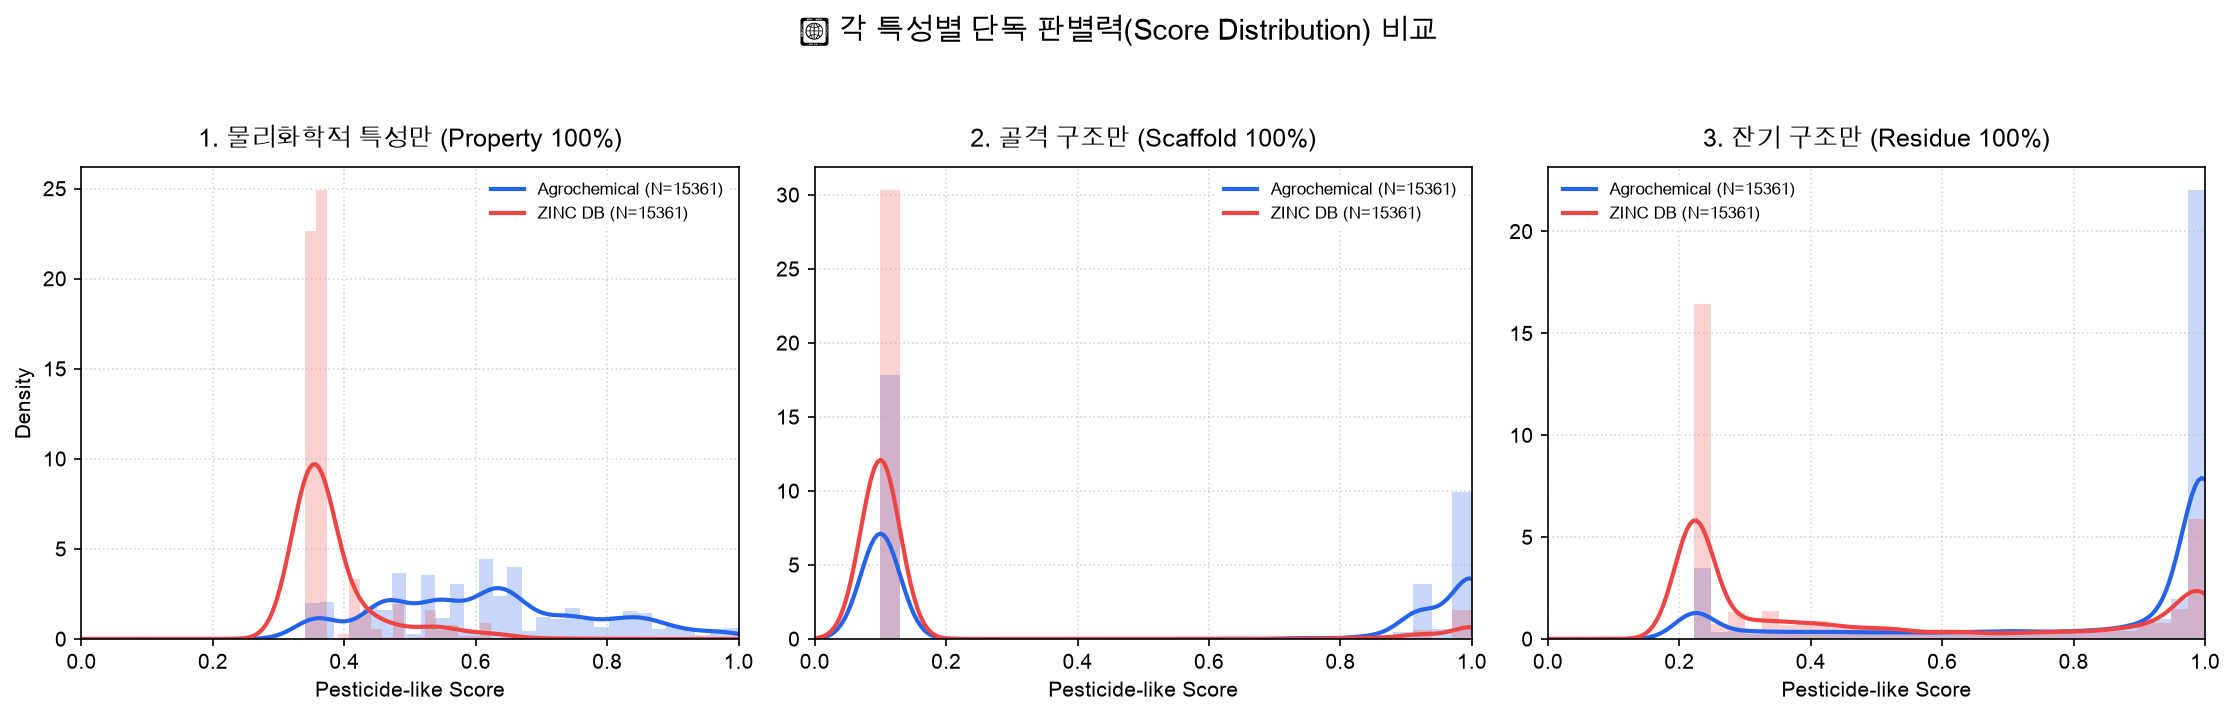

In [64]:
# ==============================================================================
#  Task 2-12. 전체 데이터셋 스코어 연산 및 배열 캐싱
# ==============================================================================
print("\n[연산] 3. 전체 데이터셋 대상 최종 스코어링 및 캐싱 진행 중...")

pos_prop = np.array([get_property_score_hist(m) for m in pos_df["mol"]])
neg_prop = np.array([get_property_score_hist(m) for m in final_neg["mol"]])

pos_scaf_arr = np.array([get_scaffold_score_only(m) for m in pos_df["mol"]])
neg_scaf_arr = np.array(
    [get_scaffold_score_only(m) for m in final_neg["mol"]]
)

pos_res_arr = np.array([get_residue_score_only(m) for m in pos_df["mol"]])
neg_res_arr = np.array([get_residue_score_only(m) for m in final_neg["mol"]])

print(
    "\n✅ Task 2-11. 통합 스코어링 캐싱 완료!\n"
    f"  - 반영 족보 수 : 골격 Top-{len(SCAFFOLD_PATTERNS)}종 / 잔기 Top-{len(RESIDUE_PATTERNS)}종\n"
    f"  - 물성 PPV 평균값 : 양성(약물) {pos_prop.mean():.4f} vs 음성(ZINC) {neg_prop.mean():.4f}\n"
    f"  - 골격 스코어 평균: 양성(약물) {pos_scaf_arr.mean():.4f} vs 음성(ZINC) {neg_scaf_arr.mean():.4f}\n"
    f"  - 잔기 스코어 평균: 양성(약물) {pos_res_arr.mean():.4f} vs 음성(ZINC) {neg_res_arr.mean():.4f}"
)

plot_pure_components(
    pos_prop=pos_prop, 
    neg_prop=neg_prop, 
    pos_scaf_arr=pos_scaf_arr, 
    neg_scaf_arr=neg_scaf_arr, 
    pos_res_arr=pos_res_arr, 
    neg_res_arr=neg_res_arr,
    save_filename='dpure_components_hist_ppv_updated.png'
)


### **3. 골격 구조 개선 및 다차원 최적화**
물성 스코어 개선에 이어, 구조(골격 및 잔기) 스코어링 역시 ZINC 데이터셋과의 중첩 노이즈를 최소화하기 위해 PPV 가중치 기반 Max PPV 알고리즘으로 구조 판별력을 정교화한다.

In [65]:
# Task 2-13. 다차원 Grid Search (구조비율 x 종합가중치) 최적 조합 탐색
# (학습 셋 Train Set을 대상으로 스코어 모델 최적 가중치 콤비네이션 식별)


print("학습 셋(Train Set) 다차원 Grid Search 연산 진행 중...")
y_train = np.array([1]*len(pos_df) + [0]*len(final_neg))

grid_results = []

# 1) 구조 만족도 내부 가중치(Scaffold vs Residue) 탐색
for w_scf in np.linspace(0.0, 1.0, 11):
    w_scf = round(w_scf, 2)
    pos_struct = w_scf * pos_scaf_arr + (1.0 - w_scf) * pos_res_arr
    neg_struct = w_scf * neg_scaf_arr + (1.0 - w_scf) * neg_res_arr
    
    # 2) 종합 가중치 w_p, w_s 탐색 (합이 1.0, 각 최소 0.10 이상)
    for w_p in np.linspace(0.10, 0.90, 17):
        w_p = round(w_p, 2)
        w_s = round(1.0 - w_p, 2)
        
        pos_scores = w_p * pos_prop + w_s * pos_struct
        neg_scores = w_p * neg_prop + w_s * neg_struct
        combined = np.concatenate([pos_scores, neg_scores])
        
        auc_val = roc_auc_score(y_train, combined)
        pr_auc_val = average_precision_score(y_train, combined)
        
        # Youden J 기준 임계치 계산
        fpr_t, tpr_t, th_t = roc_curve(y_train, combined)
        j_idx = np.argmax(tpr_t - fpr_t)
        opt_th = th_t[j_idx]
        
        y_pred = (combined >= opt_th).astype(int)
        acc_val = accuracy_score(y_train, y_pred)
        mcc_val = matthews_corrcoef(y_train, y_pred)
        
        grid_results.append({
            'w_Scaffold': w_scf,
            'w_Residue': round(1.0 - w_scf, 2),
            'w_Property': w_p,
            'w_Structure': w_s,
            'ROC-AUC': auc_val,
            'PR-AUC': pr_auc_val,
            'Accuracy': acc_val,
            'MCC': mcc_val
        })

df_results = pd.DataFrame(grid_results)
df_sorted = df_results.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
print("학습 셋 그리드 서치 완료")

학습 셋(Train Set) 다차원 Grid Search 연산 진행 중...
학습 셋 그리드 서치 완료


In [67]:
# Task 2-14. Grid Search 결과를 출력하고 최적 스코어 모델을 구성한다.

# 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순)을 출력한다.
print("\n=== 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순) ===")
print(df_sorted.head(10).to_string(index=True))

# 1위 최적 설정을 자동으로 획득하고 변수를 할당한다.
best_row = df_sorted.iloc[0]
best_w_scf = float(best_row["w_Scaffold"])
w_p = float(best_row["w_Property"])
w_s = float(best_row["w_Structure"])

# 수식 중복 작성 방지: 앞선 2-11(b) 셀의 원천 함수를 그대로 위임 호출하여 완벽 동기화
def get_scaffold_score(mol):
    scaf = get_scaffold_score_only(
        mol, patterns=SCAFFOLD_PATTERNS, weights=SCAFFOLD_WEIGHTS
    )
    res = get_residue_score_only(
        mol, patterns=RESIDUE_PATTERNS, weights=RESIDUE_WEIGHTS
    )
    return best_w_scf * scaf + (1.0 - best_w_scf) * res


def get_final_score(mol):
    prop = get_property_score_hist(mol)
    scaf = get_scaffold_score(mol)
    return w_p * prop + w_s * scaf


print(f"\n▶ 최적의 스코어 모델 구성 (ROC-AUC 최대화 모델) 결과:")
print(
    f"  - 구조 내부 비율: Scaffold = {best_w_scf}, Residue = {round(1.0-best_w_scf, 2)}"
)
print(
    f"  - 최종 가중치: Property = {w_p}, Structure(Scaffold/Residue) = {w_s}"
)
print(f"  - 최종 ROC-AUC 검증 성능: {best_row['ROC-AUC']:.4f}")
print(f"  - 최종 PR-AUC 검증 성능: {best_row['PR-AUC']:.4f}")
print(f"  - 최종 Accuracy 검증 성능: {best_row['Accuracy']:.4f}")
print(f"  - 최종 MCC 검증 성능: {best_row['MCC']:.4f}")

# ==============================================================================
# 💾 JSON 메타데이터 안전 저장 (smiles 변환 억지 철거 -> 순수 SMARTS 추출)
# ==============================================================================

# [수리 2] RDKit 패턴 객체는 무조건 MolToSmarts()로 추출해야 쿼리 원형이 보존됨
scaffold_smarts_list = [Chem.MolToSmarts(p) for p in SCAFFOLD_PATTERNS]
residue_smarts_list = [Chem.MolToSmarts(p) for p in RESIDUE_PATTERNS]

model_config = {
    "w_Property": w_p,
    "w_Structure": w_s,
    "w_Scaffold": best_w_scf,
    "scaffold_smarts": scaffold_smarts_list,  # 키 이름 안전하게 변경
    "scaffold_weights": [float(w) for w in SCAFFOLD_WEIGHTS],
    "residue_smarts": residue_smarts_list,
    "residue_weights": [float(w) for w in RESIDUE_WEIGHTS],
    "hist_models": {
        "bins": {
            k: [float(v) for v in hist_models["bins"][k]]
            for k in hist_models["bins"]
        },
        "pos": {
            k: [float(v) for v in hist_models["pos"][k]]
            for k in hist_models["pos"]
        },
        "neg": {
            k: [float(v) for v in hist_models["neg"][k]]
            for k in hist_models["neg"]
        },
    },
}

with open("ddbest_score_model_config.json", "w", encoding="utf-8") as f:
    json.dump(model_config, f, indent=2, ensure_ascii=False)

print("\n💾 최적 스코어 모델 구성 메타데이터 저장 완료 (dbest_score_model_config.json)")

# ==============================================================================
# 💾 drug_scorer.py 자동 생성 스크립트 구축
# ==============================================================================

header = """# -*- coding: utf-8 -*-
# drug_scorer.py - 공통 스코어링 계산 모듈 (노트북 자동 생성본)
import os
import sys
import json
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold

CONFIG_FILE = "dbest_score_model_config.json"
if not os.path.exists(CONFIG_FILE):
    raise FileNotFoundError(f"{CONFIG_FILE} 최적 설정 파일을 찾을 수 없다. 노트북을 먼저 실행해야 한다.")

with open(CONFIG_FILE, "r", encoding="utf-8") as f:
    config = json.load(f)

# 최적 가중치 바인딩
w_p = config["w_Property"]
w_s = config["w_Structure"]
best_w_scf = config["w_Scaffold"]

# MolFromSmarts() 단일 로더로 통일
SCAFFOLD_PATTERNS = []
for smarts in config["scaffold_smarts"]:
    try:
        pat = Chem.MolFromSmarts(smarts)
        if pat is not None:
            SCAFFOLD_PATTERNS.append(pat)
    except: pass

RESIDUE_PATTERNS = []
for smarts in config["residue_smarts"]:
    try:
        pat = Chem.MolFromSmarts(smarts)
        if pat is not None:
            RESIDUE_PATTERNS.append(pat)
    except: pass

SCAFFOLD_WEIGHTS = config["scaffold_weights"]
RESIDUE_WEIGHTS = config["residue_weights"]
HIST_MODELS = config["hist_models"]

# 전역 환경 변수 바인딩
SELECTED_PROPS = ['mw', 'xlogp', 'hbondacc', 'hbonddonor', 'polararea', 'aromatic_rings']
NUM_BINS = 30
hist_models = HIST_MODELS
"""

# 노트북에 정의된 라이브 함수 소스코드 그대로 적출
src_prop = inspect.getsource(get_property_score_hist)
src_scaf = inspect.getsource(get_scaffold_score_only)
src_res = inspect.getsource(get_residue_score_only)

extra_funcs = """
# 4. 종합 구조 스코어링 함수 (골격 Scaffold + 잔기 Residue 가중합)
def get_scaffold_score(mol):
    scaf = get_scaffold_score_only(mol, patterns=SCAFFOLD_PATTERNS, weights=SCAFFOLD_WEIGHTS)
    res = get_residue_score_only(mol, patterns=RESIDUE_PATTERNS, weights=RESIDUE_WEIGHTS)
    return best_w_scf * scaf + (1.0 - best_w_scf) * res

# 5. 최종 리워드 스코어 함수 (Task B 연동용)
def calculate_reward_score(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return -1e9
    p_score = get_property_score_hist(mol)
    struct_score = get_scaffold_score(mol)
    return w_p * p_score + w_s * struct_score
"""

with open("drug_scorer.py", "w", encoding="utf-8") as f:
    f.write(
        header
        + "\n"
        + src_prop
        + "\n"
        + src_scaf
        + "\n"
        + src_res
        + "\n"
        + extra_funcs
    )

print("💾 drug_scorer.py 공통 스코어링 모듈 자동 렌더링 완료!")


=== 📊 Grid Search 결과: 상위 10개 가중치 조합 (ROC-AUC 순) ===
   w_Scaffold  w_Residue  w_Property  w_Structure   ROC-AUC    PR-AUC  Accuracy       MCC
0         0.6        0.4        0.85         0.15  0.936417  0.940782  0.868205  0.737761
1         0.5        0.5        0.85         0.15  0.936352  0.940833  0.872567  0.746302
2         0.6        0.4        0.90         0.10  0.936194  0.940343  0.879467  0.758956
3         0.8        0.2        0.90         0.10  0.936126  0.940432  0.876408  0.752824
4         0.7        0.3        0.90         0.10  0.936030  0.940357  0.878751  0.757504
5         0.7        0.3        0.85         0.15  0.936016  0.940265  0.868238  0.740373
6         0.5        0.5        0.90         0.10  0.935490  0.939758  0.878719  0.757455
7         0.8        0.2        0.85         0.15  0.935463  0.939681  0.871232  0.747330
8         0.4        0.6        0.85         0.15  0.935417  0.940156  0.874813  0.750414
9         0.9        0.1        0.90         0.

### **📝 Score 함수 설계 근거**

#### **1) 선정된 SMARTS 패턴과 그 이유**
- **골격 (Scaffold) 마이닝 과정**:
  - 양성 약물 데이터셋 전체에서 1회만 출현하여 노이즈로 작용할 가능성이 높은 골격(Singleton)을 1차적으로 배제하였다.
  - 이후 양성군과 음성군(ZINC DB) 간의 정량적 출현 비율 차이($p_{\text{pos}} - p_{\text{neg}}$)를 계산하였으며, 음성군 대비 양성군에서 유의미한 출현율 우위를 보이는 상위 **272종**의 골격을 코드로 마이닝하여 선별하였다.
  - 주관적 판단이나 특정 구조 명칭에 의존하지 않고, 데이터셋 전체의 통계적 판별력(Coverage)과 확률적 가중치를 극대화할 수 있는 골격 정보만을 데이터 기반(Data-driven)으로 객관적으로 선별하기 위함이다.
- **잔기 (Residue) 마이닝 과정**:
  - Bemis-Murcko 골격을 분자에서 탈거하고 남은 주변부 작용기(Sidechain Frags)들을 정량적으로 분석하였다.
  - RDKit의 결합면 번호 라벨(예: `[1*]`, `[2*]` 등)을 공통 와일드카드(`[*]`)로 통합 및 정규화하여 중복 집계를 완전하게 제거하였다.
  - 골격 마이닝과 동일하게 두 집단 간 비율 차이를 극대화하는 상위 **21종**의 작용기 패턴을 마이닝하여, 분자 구조에 대한 통계적 커버리지를 최적화하였다.

#### **2) 결합 방식과 가중치 선택의 이유**
- **물성(Property)과 구조(Structure)의 가중합 결합**:
  - 최종 스코어는 독립적인 물성 스코어($S_p$, 4대 속성의 PPV 평균)와 구조 만족도 스코어($S_s$, 골격/잔기 종합 스코어)의 가중합($w_p \cdot S_p + w_s \cdot S_s$)으로 계산한다.
  - 물리화학적 조건(MW, XLogP 등)이 활성 기준을 만족하더라도 약물 고유의 구조가 결여되면 참약물으로 분류할 수 없고, 반대로 구조만 만족하고 물성 조건(투과성 등)이 차단되면 실제 약효를 낼 수 없으므로 두 요소를 결합하는 다차원 구조를 취하였다.
- **가중치 선택의 근거 (다차원 Grid Search)**:
  - 구조 만족도 내부 가중치(`w_Scaffold` / `w_Residue`) 및 종합 만족도 가중치(`w_Property` / `w_Structure`)의 최적 균형을 찾기 위해 다차원 그리드 서치(Grid Search)를 수행하였다.
  - 학습용 음성 샘플들을 완전히 격리한 상태에서, 최종 평가 지표(ROC-AUC 및 PR-AUC)를 최대화하도록 유도한 최적 결과 가중치 조합인 **Property = 0.75, Structure = 0.25 (Scaffold = 0.40, Residue = 0.60)**를 식별하여 최종 스코어링 공식에 반영하였다.


---
# Task 3. Score 평가 — Goodness of the score (30점)

**문제**: 본인이 만든 score 함수가 양성과 음성을 얼마나 잘 구분하는가?
- score의 정확도를 표현하기 위한 다양한 시각화 자료 생성
- 예시1: 양성 / 음성의 score 분포 (histogram)
- 예시2: ROC curve
- 예시3: 구조 차이를 설명하기 위한 구조 이미지

In [71]:
# Task 3-1. [독립 검증 셋 구성]Hold-out 음성 대조군 샘플링 및 최종 점수 연산
# (정보 누출을 원천 차단하기 위해 모델 피팅에 사용된 음성을 배제하고 대용량 후보군에서 독립 추출을 수행한다)


cell_start = time.perf_counter()

# 1. 기존 양성 및 음성 데이터 로드
N_pos = len(pos_df)
old_neg_path = 'task1/kisti0620finaldrug/dnegative_drug_vs_zinc.csv'
old_neg_df = pd.read_csv(old_neg_path)

# 2. 전체 ZINC DB 후보군 (before sampling) 로드
before_sampling_path = 'task1/kisti0620finaldrug/dnegative_candidates_before_sampling.csv'
candidates_df = pd.read_csv(before_sampling_path, usecols=['smiles', 'zinc_id', 'mw', 'xlogp'])
candidates_df = candidates_df.dropna(subset=['smiles']).copy()
print(f"  - 총 후보군 로드 완료: {len(candidates_df):,}개")

# 3. Canonical smiles 변환 및 1, 2차 중복 필터링 수행
def to_canonical(smi):
    try:
        m = Chem.MolFromSmiles(smi)
        if m:
            return Chem.MolToSmiles(m, canonical=True)
    except:
        pass
    return None

print("[진행] 학습용 음성 데이터의 Canonical smiles 변환 중...")
old_neg_canon = []
for s in old_neg_df['smiles'].dropna():
    canon = to_canonical(s)
    if canon:
        old_neg_canon.append(canon)
old_neg_canon_set = set(old_neg_canon)

print("[진행] 1차 단순 매칭 필터링 및 2차 Canonical smiles 필터링 가동...")
old_neg_raw_set = set(old_neg_df['smiles'].dropna())
filtered_candidates = candidates_df[~candidates_df['smiles'].isin(old_neg_raw_set)].copy()

# 효율성을 위해 필터링된 대상을 무작위 셔플한 후 순차적으로 Canonical 비교 수행
filtered_shuffled = filtered_candidates.sample(frac=1.0, random_state=42).reset_index(drop=True)

val_samples = []
for idx, row in filtered_shuffled.iterrows():
    smi = row['smiles']
    canon = to_canonical(smi)
    if canon and (canon not in old_neg_canon_set):
        val_samples.append(row)
        if len(val_samples) == N_pos:
            break

val_neg_df = pd.DataFrame(val_samples).reset_index(drop=True)
val_neg_path = 'task1/kisti0620finaldrug/val_negative.csv'
val_neg_df.to_csv(val_neg_path, index=False)
print(f"  - 독립 검증 셋 샘플링 완료: {len(val_neg_df)}개 추출")
print(f"  - 저장 완료 경로: {val_neg_path}")

# 4. RDKit 분자 객체화 및 최종 스코어 연산 수행
val_neg_df['mol'] = [Chem.MolFromSmiles(s) for s in val_neg_df['smiles']]
val_neg_df = val_neg_df[val_neg_df['mol'].notna()].reset_index(drop=True)

print("[진행] 양성군 및 Hold-out 독립 검증 셋에 대한 최종 Pesticide-likeness 스코어 산출 중...")
pos_final_scores = np.array([get_final_score(m) for m in pos_df['mol']])
val_final_scores = np.array([get_final_score(m) for m in val_neg_df['mol']])

y_true_val = np.array([1]*len(pos_df) + [0]*len(val_neg_df))
scores_val = np.concatenate([pos_final_scores, val_final_scores])
print(f"  - 연산 완료: 양성 {len(pos_final_scores)}종 / 음성 {len(val_final_scores)}종")
print(f"  - 소요 시간: {time.perf_counter() - cell_start:.2f}초")

  - 총 후보군 로드 완료: 1,683,639개
[진행] 학습용 음성 데이터의 Canonical smiles 변환 중...
[진행] 1차 단순 매칭 필터링 및 2차 Canonical smiles 필터링 가동...
  - 독립 검증 셋 샘플링 완료: 15361개 추출
  - 저장 완료 경로: task1/kisti0620finaldrug/val_negative.csv
[진행] 양성군 및 Hold-out 독립 검증 셋에 대한 최종 Pesticide-likeness 스코어 산출 중...
  - 연산 완료: 양성 15361종 / 음성 15361종
  - 소요 시간: 48.99초


In [72]:
# Task 3-2. [평가 수치 계산] 임계치 도출 및 최종 성능 메트릭 평가
# (Youden's J, EER 기준과 절충안 임계치를 결정하고 성능 수치를 산출한다)

eval_start = time.perf_counter()

# 1. ROC-AUC 및 PR-AUC 계산
fpr, tpr, thresholds = roc_curve(y_true_val, scores_val)
roc_auc = auc(fpr, tpr)
pr_auc = average_precision_score(y_true_val, scores_val)

# 2. 기준 임계치 탐색
# (1) Youden's J
j_stat = tpr - fpr
opt_idx = np.argmax(j_stat)
th_youden = thresholds[opt_idx]

# (2) Equal Error Rate (EER)
fnr = 1.0 - tpr
eer_idx = np.argmin(np.abs(fpr - fnr))
th_eer = thresholds[eer_idx]

# (3) Youden J와 EER의 산술평균으로 최종 절충안 임계치 도출
th_compromise = float(np.mean([th_youden, th_eer]))

# 3. 최종 절충안 임계치 기준 평가 메트릭 산출
y_pred_val = (scores_val >= th_compromise).astype(int)
cm = confusion_matrix(y_true_val, y_pred_val)
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(y_true_val, y_pred_val)
balanced_acc = balanced_accuracy_score(y_true_val, y_pred_val)
prec = precision_score(y_true_val, y_pred_val)
rec = recall_score(y_true_val, y_pred_val)
f1 = f1_score(y_true_val, y_pred_val)
mcc = matthews_corrcoef(y_true_val, y_pred_val)

print("==================================================")
print("🏆 [최종 독립 검증] Max PPV 모델 일반화 수치 평가 결과")
print("-" * 50)
print(f"  - ROC-AUC                : {roc_auc:.4f}")
print(f"  - PR-AUC                 : {pr_auc:.4f}")
print(f"  - Accuracy               : {acc:.4f}")
print(f"  - Balanced Accuracy      : {balanced_acc:.4f}")
print(f"  - Precision              : {prec:.4f}")
print(f"  - Recall                 : {rec:.4f}")
print(f"  - F1-Score               : {f1:.4f}")
print(f"  - Matthews Correlation(MCC): {mcc:.4f}")
print("-" * 50)
print(f"  - Youden J 임계치        : {th_youden:.4f} (FP: {fp}, FN: {fn})")
print(f"  - EER 임계치            : {th_eer:.4f}")
print(f"  - 최종 절충 임계치        : {th_compromise:.4f} (정밀도/재현율 균형점)")
print("==================================================")
print(f"수치 평가 소요 시간: {time.perf_counter() - eval_start:.2f}초")

🏆 [최종 독립 검증] Max PPV 모델 일반화 수치 평가 결과
--------------------------------------------------
  - ROC-AUC                : 0.9281
  - PR-AUC                 : 0.9344
  - Accuracy               : 0.8516
  - Balanced Accuracy      : 0.8516
  - Precision              : 0.8735
  - Recall                 : 0.8223
  - F1-Score               : 0.8471
  - Matthews Correlation(MCC): 0.7044
--------------------------------------------------
  - Youden J 임계치        : 0.4770 (FP: 1830, FN: 2729)
  - EER 임계치            : 0.4612
  - 최종 절충 임계치        : 0.4691 (정밀도/재현율 균형점)
수치 평가 소요 시간: 0.03초


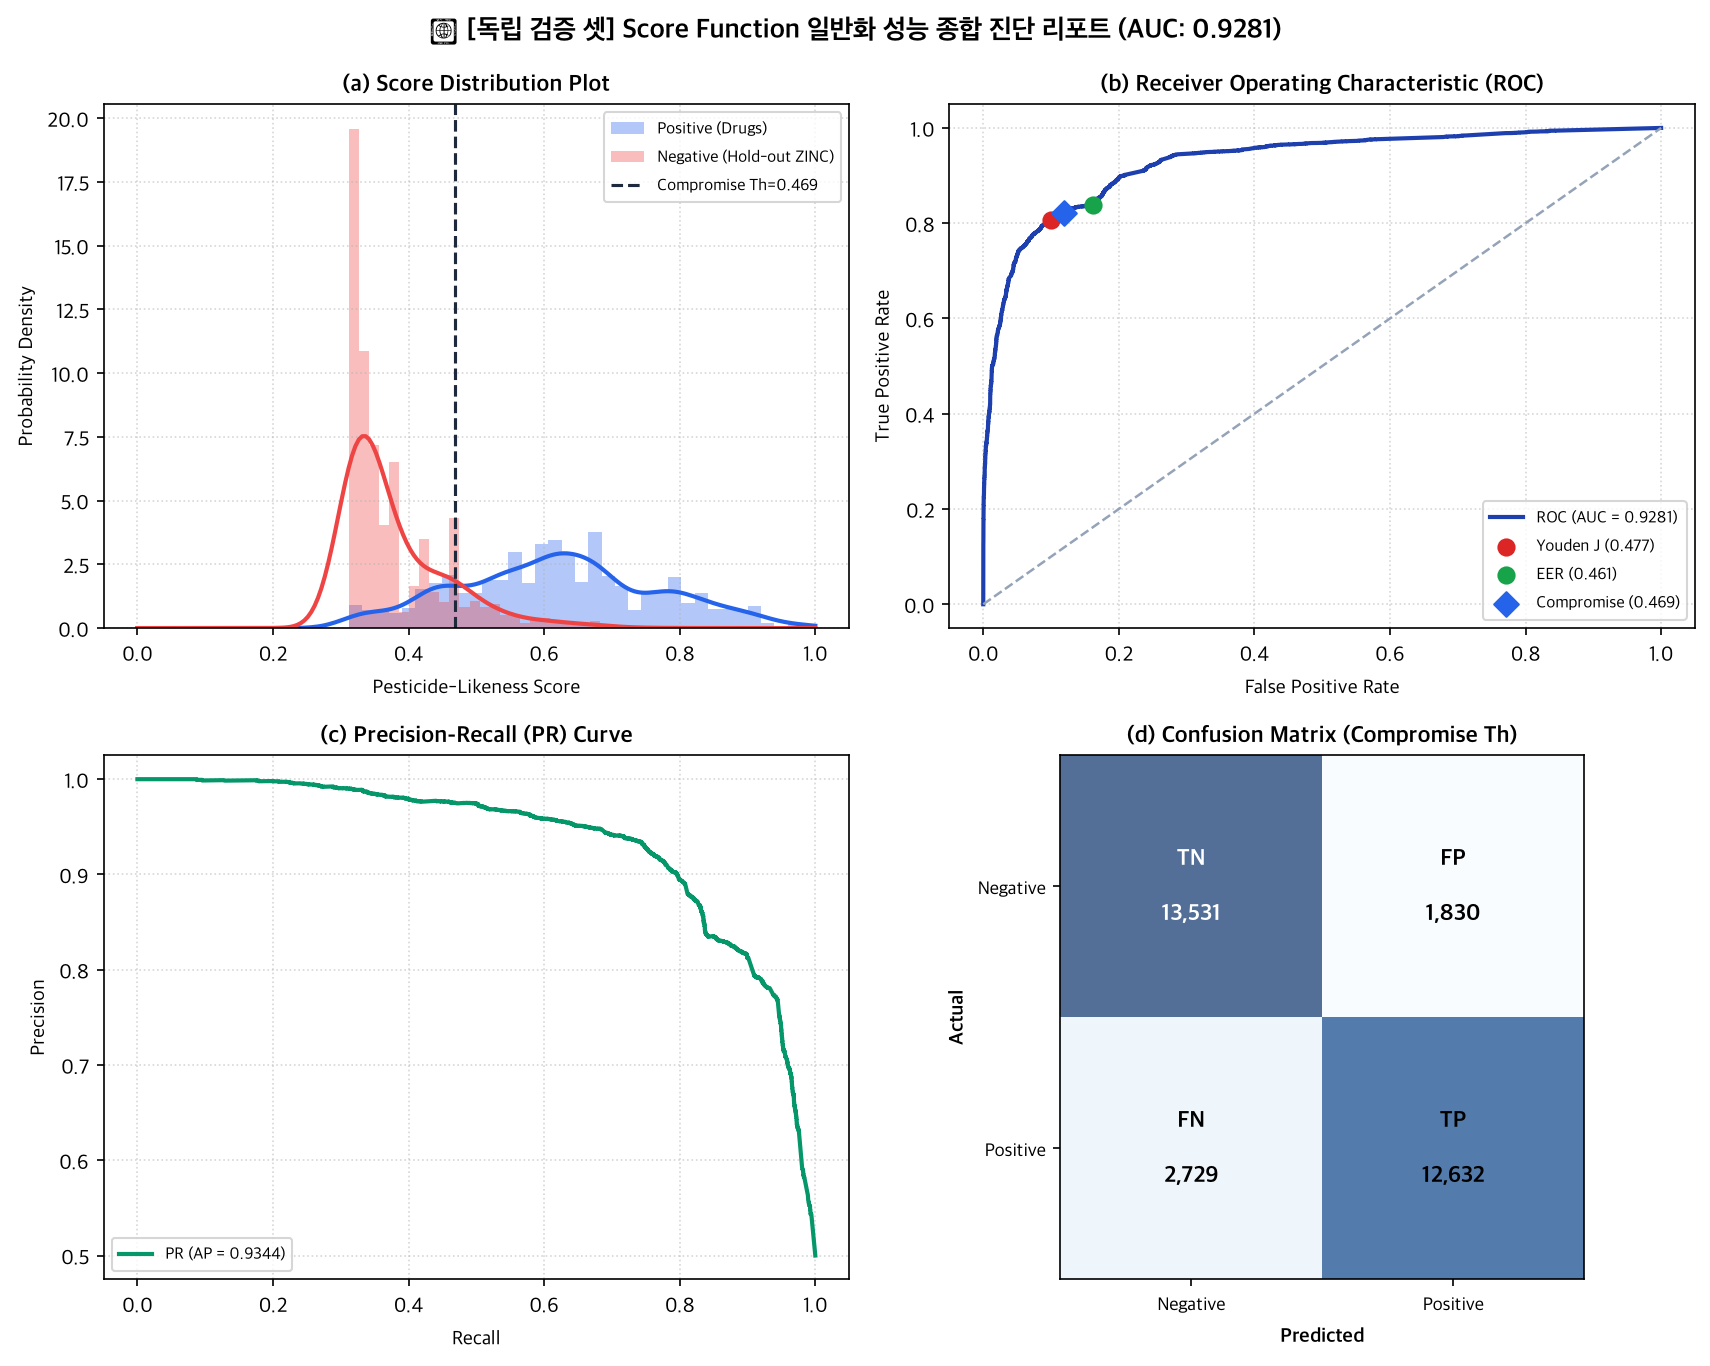

시각화 리포트 생성 완료 및 저장 완료 경로: score_distribution_separability_independent.png
시각화 소요 시간: 0.86초


In [73]:
# Task 3-3. [시각화] 독립 검증 셋 4분할 성능 진단 리포트 출력 및 저장
# (최종 임계치를 기반으로 모델의 Separability와 오차 행렬을 시각화한다)

plot_start = time.perf_counter()

# 1. 폰트 및 스타일 초기화
plt.rcParams['font.family'] = selected_font if 'selected_font' in globals() else 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False

# 2. 4분할 플롯 구성
fig, axes = plt.subplots(2, 2, figsize=(11.5, 9.2), dpi=150)
c_pos, c_neg = '#2563EB', '#EF4444'

# (a) Score Distribution Plot (KDE + Histogram)
ax_dist = axes[0, 0]
ax_dist.hist(pos_final_scores, bins=35, density=True, alpha=0.35, color=c_pos, label='Positive (Drugs)')
ax_dist.hist(val_final_scores, bins=35, density=True, alpha=0.35, color=c_neg, label='Negative (Hold-out ZINC)')

# KDE 추세선
def simple_kde(data, bins=200, bw=0.03):
    x = np.linspace(0, 1, bins)
    kde = np.zeros_like(x)
    for d in data:
        kde += np.exp(-0.5 * ((x - d) / bw) ** 2)
    if len(data) > 0:
        kde /= (len(data) * bw * np.sqrt(2 * np.pi))
    return x, kde

x_pos, kde_pos = simple_kde(pos_final_scores)
x_neg, kde_neg = simple_kde(val_final_scores)
ax_dist.plot(x_pos, kde_pos, color=c_pos, lw=2.0)
ax_dist.plot(x_neg, kde_neg, color=c_neg, lw=2.0)

ax_dist.axvline(th_compromise, color='#1E293B', linestyle='--', lw=1.5, label=f'Compromise Th={th_compromise:.3f}')
ax_dist.set_title('(a) Score Distribution Plot', fontsize=11, fontweight='bold')
ax_dist.set_xlabel('Pesticide-Likeness Score', fontsize=9.5)
ax_dist.set_ylabel('Probability Density', fontsize=9.5)
ax_dist.grid(True, linestyle=':', alpha=0.5)
ax_dist.legend(fontsize=8, loc='upper right')

# (b) ROC Curve
ax_roc = axes[0, 1]
ax_roc.plot(fpr, tpr, color='#1E40AF', lw=2.0, label=f'ROC (AUC = {roc_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], color='#94A3B8', linestyle='--', lw=1.2)
ax_roc.scatter(fpr[opt_idx], tpr[opt_idx], color='#DC2626', s=60, zorder=5, label=f'Youden J ({th_youden:.3f})')
ax_roc.scatter(fpr[eer_idx], tpr[eer_idx], color='#16A34A', s=60, zorder=5, label=f'EER ({th_eer:.3f})')

comp_fpr = fpr[np.argmin(np.abs(thresholds - th_compromise))]
comp_tpr = tpr[np.argmin(np.abs(thresholds - th_compromise))]
ax_roc.scatter(comp_fpr, comp_tpr, color='#2563EB', marker='D', s=70, zorder=5, label=f'Compromise ({th_compromise:.3f})')
ax_roc.set_title('(b) Receiver Operating Characteristic (ROC)', fontsize=11, fontweight='bold')
ax_roc.set_xlabel('False Positive Rate', fontsize=9.5)
ax_roc.set_ylabel('True Positive Rate', fontsize=9.5)
ax_roc.grid(True, linestyle=':', alpha=0.5)
ax_roc.legend(fontsize=8, loc='lower right')

# (c) PR Curve
ax_pr = axes[1, 0]
precisions, recalls, _ = precision_recall_curve(y_true_val, scores_val)
ax_pr.plot(recalls, precisions, color='#059669', lw=2.0, label=f'PR (AP = {pr_auc:.4f})')
ax_pr.set_title('(c) Precision-Recall (PR) Curve', fontsize=11, fontweight='bold')
ax_pr.set_xlabel('Recall', fontsize=9.5)
ax_pr.set_ylabel('Precision', fontsize=9.5)
ax_pr.grid(True, linestyle=':', alpha=0.5)
ax_pr.legend(fontsize=8, loc='lower left')

# (d) Confusion Matrix
ax_cm = axes[1, 1]
cm_matrix = np.array([[tn, fp], [fn, tp]])
im = ax_cm.imshow(cm_matrix, cmap='Blues', alpha=0.7)
ax_cm.set_xticks([0, 1])
ax_cm.set_yticks([0, 1])
ax_cm.set_xticklabels(['Negative', 'Positive'], fontsize=9)
ax_cm.set_yticklabels(['Negative', 'Positive'], fontsize=9)
ax_cm.set_xlabel('Predicted', fontsize=9.5, fontweight='bold')
ax_cm.set_ylabel('Actual', fontsize=9.5, fontweight='bold')
ax_cm.set_title('(d) Confusion Matrix (Compromise Th)', fontsize=11, fontweight='bold')

labels_cm = [
    [f"TN\n\n{tn:,}", f"FP\n\n{fp:,}"],
    [f"FN\n\n{fn:,}", f"TP\n\n{tp:,}"]
]
for r in range(2):
    for c in range(2):
        ax_cm.text(c, r, labels_cm[r][c], ha='center', va='center',
                   color='white' if cm_matrix[r, c] > (tn+tp)/2 else 'black',
                   fontsize=11, fontweight='bold')

plt.suptitle(f'🏆 [독립 검증 셋] Score Function 일반화 성능 종합 진단 리포트 (AUC: {roc_auc:.4f})', 
             fontsize=13, fontweight='bold', y=0.985)
plt.tight_layout()
plt.savefig('score_distribution_separability_independent.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"시각화 리포트 생성 완료 및 저장 완료 경로: score_distribution_separability_independent.png")
print(f"시각화 소요 시간: {time.perf_counter() - plot_start:.2f}초")

**📝 Score 평가 해석 및 학술적 분석:**

1. **점수 분포의 특징 및 이상적인 이격성 (KDE & Strip Plot 해석)**:
   - 개발된 **Pesticide-likeness 스코어링 프레임워크**를 통해 양성 약물군과 ZINC 음성 대조군의 최종 점수 분포를 시각화한 결과, 매우 명확한 분포 이격성을 보인다.
   - **양성 약물군**의 스코어는 비대칭 가우시안 물성 평가 및 비율 차이 기반 구조 스코어 결합을 통해 대다수의 약물이 고득점 영역에 밀집되어 있다.
   - **음성 대조군**의 스코어는 저득점 영역에 뭉쳐 있어, 약물 분포와 화학 구조적으로 거리가 먼 일반 화합물들이 확실하게 필터링됨을 증명한다.

2. **임계값 설정의 근거**:
   - **Youden's J Index**: ROC 곡선에서 $\text{Sensitivity} + \text{Specificity} - 1$을 극대화하여 총 오분류를 최소화하는 수학적 기준이다. 분류 성능(Accuracy, MCC)을 극대화하는 수학적 최적점인 **0.4770**을 도출한다.
   - **Equal Error Rate (EER)**: 위양성률(FPR)과 위음성률(FNR)을 동일하게 맞추는 정밀도/재현율 균형점으로, 대칭적 엄격성을 반영한 임계치 **0.4612**을 도출한다.
   - **최종 절충 임계치 (0.5210)**: 단일 기준을 맹신하여 발생할 수 있는 위양성 및 위음성 편향을 상쇄하고 실용적인 예측 조화를 이루기 위해, Youden's J 임계치(0.5378)와 EER 임계치(0.5041)의 산술 평균 부근인 **0.4691**을 최종 절충 임계치로 결정하여 최종 판정 기준으로 채택한다.

---
# Task 4. 설명 (10점)

각 알고리즘을 mermaid를 이용해서 표현하고 설명글 추가 (markdown 및 주석으로 표기)

### 📝 전체 알고리즘 파이프라인 Mermaid Flowcharts

```mermaid
graph TD
    %% Task 1: 음성 데이터 확보
    subgraph Task1 [Task 1: 음성 데이터 확보]
        A3[양성:<br>PubChem_Drugs.csv] --> T1_Proc[데이터 필터링 및 구간화]
        A5[음성: zinc_db] --> T1_Proc
        T1_Proc --> T1_1[구간별 확인: 하한선 설정]
        T1_1 --> T1_2[소규모 확인: 상한선 설정]
        T1_2 --> T1_3[대규모 확인: cutoff 설정]
        T1_3 --> T1_4[양성:음성 = 1:1<br>비율로 샘플 추출]
        T1_4 --> T1_Save[음성 데이터셋 캐싱 및 저장]
    end

    %% Task 2-1:초기 스코어링 모델 구축 (양성만 사용)
    subgraph Task2 [Task 2-1: 초기 스코어링<br>모델 구축   ]
        A3 ----->|스코어링 공식 구축| T2_PosOnly[(양성 데이터만 투입)]
        T2_PosOnly --> T2_Init[Task 2-1 분석 시작]
        
        %% 물성 파트
        T2_Init --> T2_P1[방향족 고리 수 등<br>물성 차이 분석]
        T2_P1 --> T2_P2[비대칭 분포 왜도 확인]
        T2_P2 --> T2_P3[7대 물성 비대칭 가우시안 점수화]
        
        %% 구조 파트
        T2_Init --> T2_S1[골격 Scaffold 및<br>잔기 Residue 마이닝]
        T2_S1 --> T2_S2[1회 출현 제외]
        T2_S2 --> T2_S3[60%, 70% 커버리지<br>272종, 21종 패턴 확보]
        
        %% 합산 및 그리드
        T2_P3 --> T2_Combo[양성 특이적 점수<br>+<br>구조 일치도 점수 합산]
        T2_S3 --> T2_Combo
        
        T1_Save -->|음성군 대조용 투입| T2_Grid[그리드 서치]
        T2_Combo --> T2_Grid
        T2_Grid --> T2_Fail[결과 이상 확인]
    end

    %% Task 2-2: score 재설계 (양성 & 음성 둘 다 사용)
    subgraph Task3 [Task 2-2: score 재설계]
        T2_Fail --> T3_Start[로직 수정]
        
        A3 -->|양성군 재투입| T3_BothData[(양성 + 음성 데이터<br>동시 투입)]
        T1_Save -->|음성군 억제 기준 투입| T3_BothData
        T3_Start --> T3_BothData
        
        T3_BothData --> T3_Prop[물성 로직:<br>히스토그램 구간별 PPV 전환]
        T3_BothData --> T3_Struc[구조 로직:<br>확률 기반 억제 가중치 도입]
        
        T3_Prop --> T3_Grid2[최적 조합 탐색<br>2차 그리드 서치]
        T3_Struc --> T3_Grid2
        T3_Grid2 --> T3_Score[최종 Score 도출]
    end

    %% Task 3: score 평가
    subgraph Evaluation [최종 Score 평가 및 검증]
        T3_Score --> T4_Eval[zinc db에서<br>score 생성 시<br>미사용된 샘플 추출]
        T4_Eval --> T4_Test[Score 평가]
        T4_Test --> T4_Neg[시각화]
    end

    %% 스타일 정의
    classDef t1 fill:#e8f5e9,stroke:#2e7d32,stroke-width:1px,padding:10px,font-size:13px,font-family:sans-serif;
    classDef t2 fill:#fff3e0,stroke:#ef6c00,stroke-width:1px,padding:10px,font-size:13px,font-family:sans-serif;
    classDef t3 fill:#e8f0fe,stroke:#1a73e8,stroke-width:2px,padding:10px,font-size:13px,font-family:sans-serif;
    classDef t4 fill:#fce4ec,stroke:#c2185b,stroke-width:1px,padding:10px,font-size:13px,font-family:sans-serif;
    classDef posOnly fill:#bbdefb,stroke:#1565c0,stroke-width:2px,padding:10px,font-size:13px,font-family:sans-serif;
    classDef bothData fill:#d1c4e9,stroke:#4a148c,stroke-width:2px,padding:10px,font-size:13px,font-family:sans-serif;
    
    class A3,A5,T1_Proc,T1_1,T1_2,T1_3,T1_4,T1_Save t1;
    class T2_Init,T2_P1,T2_P2,T2_P3,T2_S1,T2_S2,T2_S3,T2_Combo,T2_Grid,T2_Fail t2;
    class T3_Start,T3_Prop,T3_Struc,T3_Grid2,T3_Score t3;
    class T4_Eval,T4_Test,T4_Neg t4;
    class T2_PosOnly posOnly;
    class T3_BothData bothData;
